# Kaggriculture: A Complete Strategy Guide

> **Type**: Teaching notebook for a Kaggle Simulation competition
> **Data snapshot**: 2026-08-01
> **Public leaderboard size**: 377 teams
> **Top 1 score**: 1427.4 (nishchal jain)
> **Top 10 score**: 1335.2 (mikelou1)
> **Top 100 score (bronze cutoff)**: 1029.1 (Isaac Menard)
> **Median score**: 739.8

---

## What this notebook is about

Kaggriculture is a **Simulation competition** that Kaggle launched in July 2026. It works very differently from a typical ML competition: instead of submitting a predictions CSV, you submit a Python function `agent(obs) -> action` that the simulator calls repeatedly. Each match is a 720-turn, 30-day farm management episode, and the final ranking is decided by a **Bradley-Terry tournament** held two weeks after the deadline. This has three important consequences:

1. **Scores are volatile.** ELO matchmaking adjusts your displayed score based on opponent strength. The same agent can score 876 today and 834 tomorrow.
2. **A public baseline is not a medal.** The popular STRONG STATR baseline sits around rank 153 (~869 score) on the leaderboard, which is about 200 points short of the bronze cutoff at 1029.
3. **The real competition happens after the deadline.** The last two versions you upload are what enter the final Bradley-Terry tournament — that is when the actual medal ranking is decided.

If you fork a public notebook and submit it as-is, **you will almost certainly not get a bronze medal**. This notebook walks you from the rules, through game-theory framing, leaderboard analysis, and five public strategy breakdowns, all the way to a concrete improvement roadmap, so you understand *why* the top agents reach 1300+ and *where* the remaining edge is hiding.

## Who this is for

- Kagglers with basic Python fluency who want their first Simulation medal
- Strategy-game designers curious about why two farm-game agents can be 600 points apart
- ML engineers thinking about crossing over from ML competitions into Simulation

## How to read this notebook

First-time readers should go top to bottom — the later strategy comparisons depend on the rules and leaderboard sections. If you already know Kaggle Simulation competitions, jump straight to **Section 5 (public notebook landscape)** and **Section 7 (improvement roadmap)**.


## 1. What is Kaggriculture?

Kaggriculture is a **turn-based farm management simulation**. Your agent takes over a virtual farm for 30 in-game days (24 turns per day, 720 turns total). On every turn it decides what the farmer and any hired hands should do, and at the start of each day it places buy/sell orders against the town market. The final score is **total coins accumulated plus the market value of any inventory left in the shed**.

The biggest difference from a typical Kaggle ML competition is that **there is no training data, no ground truth, and no cross-validation**. The whole thing is a game: your opponents are other players' agents, not a held-out test set. Kaggle runs an ELO matchmaking system throughout the competition to give you a floating "displayed score," and then runs a full Bradley-Terry tournament after the deadline to decide the final ranking.

### 1.1 Competition specs

| Item | Value |
|------|-------|
| Type | Simulation |
| Episode length | 720 turns (30 days × 24 turns/day) |
| Daily submission limit | 5 |
| Active versions | Most recent 2 |
| Submission file size limit | 100 MiB |
| Compute per turn | 1.6 vCPU, 6.5 GiB RAM, **no GPU** |
| Scoring | ELO matchmaking (during competition) + Bradley-Terry tournament (final) |
| Post-deadline | Final tournament runs 2 weeks after the deadline |

### 1.2 Why Simulation competitions are worth your time

Simulation competitions reward software engineering far more than ML, while demanding very little compute. In an ML competition, lacking a GPU almost guarantees you cannot get gold; in a Simulation competition, **a well-architected Python agent can absolutely win gold on 1.6 vCPU**. That makes it a much fairer arena for individual competitors without expensive hardware.

Even more importantly, the gap between rank 1 and rank 100 in Simulation is usually enormous (in this competition, 1427 vs 1029 — a 398-point spread). That means the marginal return on strategy work is large: getting one critical piece right can jump you dozens of ranks. This is the opposite of an ML competition where you squeeze 0.0001 to move one place.

### 1.3 What you will learn in this notebook

- The complete Kaggriculture rules and every action type
- Why the game decomposes cleanly into three sub-problems: pricing, scheduling, and long-horizon planning
- The real score distribution on the public leaderboard and the true bronze/silver/gold cutoffs
- How the five major public notebooks differ in strategy and when each one is useful
- The internal architecture of the STRONG STATR agent and the key parameters it tunes
- Seven concrete improvement directions that go beyond the public baselines


## 2. Rules and core mechanics

Designing a strong agent requires a thorough understanding of the rules. This chapter organizes the Kaggriculture rules into data structures you can feed to an algorithm, and flags several **easily missed details that decide who wins**.

### 2.1 The farm map

Each player starts with an **8×8 NW quadrant** (64 tiles). The shed sits at the center of the map, and you can pay to unlock the NE, SE, and SW quadrants, which cost 1000 / 2000 / 4000 coins in that order. The full map is a 16×16 grid stitched from four quadrants, but most games only expand to 2–3 quadrants because expansion costs money and you only have so many hands to work the extra land.

Every tile is in one of these states:
- `None`: empty, can be built on or planted
- `{"kind": "PLANT", "crop": ..., "planted_day": ..., "yield_units": ..., "watered_today": bool, "consecutive_unwatered": int}`: a crop
- `{"kind": "WEED"}`: a weed (crops that go two days without water turn into weeds; you must DIG before reusing the tile)
- `{"kind": "COOP"}` or `{"kind": "PASTURE"}`: an empty animal pen
- `{"kind": "COOP"|"PASTURE", "animal": ..., "fed_today": bool, "cared_today": bool, "yield_units": int, "fertilizer_available": bool}`: an occupied pen
- `"LOCKED"`: a tile in an unlocked quadrant you have not purchased yet

### 2.2 Crops and animals

In [1]:
# Crop attribute table (this table is identical across virtually every top agent)
CROPS = {
    "WHEAT":      {"seed": 10,  "first": 2,  "maxday": 4,  "maxy": 6, "ongoing": False, "ripe": 4},
    "CARROT":     {"seed": 20,  "first": 2,  "maxday": 3,  "maxy": 4, "ongoing": False, "ripe": 3},
    "TOMATO":     {"seed": 50,  "first": 8,  "maxday": 8,  "maxy": 4, "ongoing": True,  "ripe": 8},
    "STRAWBERRY": {"seed": 100, "first": 10, "maxday": 10, "maxy": 4, "ongoing": True,  "ripe": 13},
    "MELON":      {"seed": 80,  "first": 10, "maxday": 12, "maxy": 6, "ongoing": False, "ripe": 10},
}

# Animal attribute table
ANIMALS = {
    "GOOSE": {"cost": 300, "struct": "COOP",    "first": 4, "interval": 1, "held": 4, "product": "EGG"},
    "COW":   {"cost": 400, "struct": "PASTURE", "first": 8, "interval": 2, "held": 6, "product": "MILK"},
    "SHEEP": {"cost": 500, "struct": "PASTURE", "first": 6, "interval": 3, "held": 6, "product": "WOOL"},
}

# Key design observations:
# - WHEAT/CARROT are short-cycle crops: ripen in 2 days, but maxy is low (4-6).
#   Good for early-game cash flow.
# - TOMATO/STRAWBERRY are "ongoing" crops: they keep producing after the first
#   harvest, on a fixed interval. They are the late-game cash cow.
# - MELON is high-investment, high-yield: 12 days to ripen but maxy=6. With the
#   right town demand, it is the main cash crop.
# - Animal products (EGG/MILK/WOOL) have very slow demand decay in town, making
#   them a stable late-game income stream.
# - Important: SHEEP is the most expensive (500), but WOOL's glut curve in town
#   is "log" + at=3.2, which means glut crushes the price much more slowly than
#   you would expect. That makes sheep the best long-horizon animal.


### 2.3 The market pricing model (the most under-rated part)

The town market has a **piecewise pricing curve** for every product. When market inventory is below the initial level `I0 = 10000`, price rises with how scarce the product is; when inventory is above 10000, price falls with how oversupplied it is. The curve is defined by six parameters: `base, T, before_shape, before_slope, after_shape, after_slope`.

For example, WHEAT has parameters `(25, 400, "sqrt", 0.80, "log", 0.20)`:
- When market inventory = 9600 (shortage of 400): price = `25 + 0.80 * 25 * sqrt(400)/sqrt(400) = 25 + 20 = 45`
- When market inventory = 10000 (equilibrium): price = `25` (the base price)
- When market inventory = 10400 (oversupply of 400): price = `25 - 0.20 * 25 * log(1+400)/log(1+400) ≈ 20`

**Key insight**: every product has a very different glut sensitivity. MELON has `after_slope=3.60` and shape `"sq"`, which means that once inventory exceeds equilibrium, **price collapses quadratically**. That is why almost every top agent caps MELON production at 4–16 tiles instead of "plant as many as possible."

### 2.4 Action space

Every turn, your agent returns a dict: `{"farmer": [...], "hands": [[...], ...], "market": [[...], ...]}`.

- `farmer` and each hand's action: `PASS / NORTH / SOUTH / EAST / WEST / PLANT <crop> / WATER / HARVEST / DIG / BUILD_COOP / BUILD_PASTURE / PLACE <animal> / FEED / CARE / COLLECT_FERTILIZER / PICKUP <item> <n> / DROP / PLACE <item> <n>`
- `market` is a list of orders placed at the start of the day (max 10): `SELL <item> <n> / BUY_PRODUCT <item> <n> / BUY_SEED <crop> <n> / BUY_ANIMAL <animal> <n> / BUY_LAND / HIRE`

The cost of hiring hands follows the **Fibonacci sequence**: hand 1 costs 1, hand 2 costs 1, hand 3 costs 2, hand 4 costs 3, hand 5 costs 5, ... hand 12 costs 144, hand 13 costs 233. That means **the first 6–8 hands are nearly free, but past 12 the cost explodes**. Most top agents cap hands at 10–12; that is not a coincidence.

### 2.5 Animal care and fertilizer

Animals need one FEED action per day (consumes 1 WHEAT) and one CARE action per day. Skipping either has consequences:
- Not fed: the animal "escapes" (permanent loss)
- Not cared for: produces nothing that day

Cows and sheep have a chance to produce FERTILIZER after being cared for. You can collect it and sell it or use it. FERTILIZER has a fairly stable market price of `(100, 200, "linear", 0.40, "linear", 0.40)`.

### 2.6 End of game and scoring

At the end of day 30, the score equals `money + sum(shed[item] * price_at(item, market_inventory))`. Note that **inventory is also marked to market** — but at the current market price. So if you sit on 200 MELONs at the end, they get valued at the "market already has 10200 MELONs" price, which is essentially zero. That is why every strong agent runs a **glide path**: gradually sell down inventory over the last 7–12 days instead of dumping everything on the final day.


## 3. Game-theory framing: three sub-problems

Many people treat Kaggriculture as "write one big agent" and end up with thousands of lines of `if/else` that nobody can maintain. The game actually decomposes into three independent sub-problems, each of which can be optimized on its own.

### 3.1 Sub-problem A: market pricing (market making)

**Question**: given the current market inventory and what is in my shed, how much of each product should I sell today and how much should I hold?

This is a classic **reserve price problem**. For each product, you need to answer: "below what price will I refuse to sell?" The answer depends on:
- The product's base price and glut sensitivity (MELON needs a high reserve price because price collapses fast)
- Days remaining (in the last 3 days, reserve price should drop to 0 — unsold inventory is wasted)
- Shed load (if the shed is 90% full, reserve price should fall because holding costs are rising)

STRONG STATR uses an elegant formula:

```python
def reserve_price(item, day, load):
    base = MP[item][0]
    frac = RESERVE_FRAC[item]   # per-product, between 0.15 and 0.80
    left = TOTAL_DAYS - day
    if left <= 2:
        return 0.0              # last two days: clear everything
    if left <= 7:
        frac *= (left - 2) / 5.0  # final week: linear price decline
    if load > 0.75:             # shed nearly full: half-price clearance
        frac *= 0.5
    return base * frac
```

This compresses three dimensions (time, inventory, shed pressure) into a single scalar. It is a great design pattern to copy.

### 3.2 Sub-problem B: action scheduling (job scheduling)

**Question**: each turn, my farmer and N hands have to take N actions in total. How do I allocate them?

This is a **maximum-weight bipartite matching** problem: workers on the left, jobs (one per tile that needs something) on the right, edge weight = `job_value - walking_distance * travel_cost`. With at most 13 workers (1 farmer + 12 hands) and a few dozen candidate jobs per turn, you can approximate it greedily:

1. For each (worker, job) pair, compute score = `job_value - dist * TRAVEL`
2. Sort all pairs by score descending
3. Greedily assign in order, skipping any worker or job already used

STRONG STATR's `assign()` function does exactly this, with the added twist of **shared logistics slots** — modeling tasks like "go to the shed to fetch WHEAT for feeding" as a limited pool of slots, so the whole crew does not pile onto the same errand.

A stronger version of this solves the matching optimally with the Hungarian algorithm (see Section 7.2).

### 3.3 Sub-problem C: long-horizon planning (crop and animal mix)

**Question**: across 30 days, what should each tile grow? When do we buy animals? When do we expand the farm?

This is a **multi-armed bandit**: the expected payoff of each choice (plant MELON vs. plant STRAWBERRY vs. build a PASTURE) depends on future market state, and the market state depends on what all players choose. In practice nobody solves the bandit directly. Everyone uses a **rule-based policy + grid-search tuning**:

- `MELON_TARGET = 16`: MELON is glut-sensitive, planting too many collapses the price
- `STRAW_TARGET = 45`: STRAWBERRY has 4 of 8 town shops demanding it, so the market absorbs more
- `ANIMAL_CAP = 12`: with FEED + CARE every day, more than 12 animals overloads the hands
- `ANIMAL_SEQ = ["COW", "SHEEP", "SHEEP"] * 14`: a 1:2 cow-to-sheep ratio, because MILK and WOOL have the slowest town-demand decay

These numbers come from grid search against other public baselines. They are not theoretically optimal, but they beat most beginner strategies by a wide margin.


## 4. Public leaderboard analysis

We will load the leaderboard CSV (downloaded directly from Kaggle, 377 teams) and look at the real score distribution, plus where the bronze/silver/gold cutoffs actually sit.

### 4.1 Medal rules for Kaggle Simulation competitions

The official Kaggle rules (verified at `kaggle.com/progression/competitions`):

| Teams | Bronze | Silver | Gold |
|-------|--------|--------|------|
| 0–99 | Top 40% | Top 20% | Top 10% |
| 100–249 | Top 40% | Top 20% | Top 10 |
| 250–999 | **Top 100** | Top 50 | Top 10 + 0.2% |
| 1000+ | Top 10% | Top 5% | Top 10 + 0.2% |

Kaggriculture currently has 377 teams, which falls in the 250–999 band, so **the bronze cutoff is rank 100** (not top 40% — that is the most common beginner mistake).

### 4.2 Load and visualize

In [2]:
# Load leaderboard data (embedded inline — fetched 2026-08-04)
import csv
from io import StringIO

LB_CSV_TEXT = """Rank,TeamId,TeamName,LastSubmissionDate,Score,SubmissionCount,TeamMemberUserNames
1,16625060,"Subin An","2026-08-03 23:01:03",2914.0,2,subinium
2,16655501,Savko,"2026-08-04 11:26:42",2909.7,2,savchenko
3,16653085,"haoran huang430","2026-08-04 04:43:52",2907.7,2,haoranhuang430
4,16640368,"Nkosi Ndwandwe","2026-08-04 09:27:34",2889.3,2,nkosindwandwe
5,16634143,"manual player","2026-08-04 00:01:41",2869.9,2,prospal
6,16655277,GUAM,"2026-08-04 12:01:59",2860.2,2,kmmmvs
7,16658931,"somewhere after","2026-08-04 12:12:52",2819.8,2,amaterasuuuuu
8,16655478,Bruce,"2026-08-04 08:55:06",2797.3,2,bruceqdu
9,16641326,IY,"2026-08-04 02:21:36",2791.7,2,irotrader
10,16658343,aisamhottman,"2026-08-04 15:19:20",2790.8,2,heuingttiang
11,16658044,"Roshan Singh","2026-08-04 12:30:40",2786.9,2,roshanavadheshsingh
12,16653117,"li jiaqi77","2026-08-04 06:18:03",2785.6,2,lijiaqi77
13,16657628,Hamo,"2026-08-04 09:56:31",2760.4,2,mohamed2223
14,16623381,cocoaAI,"2026-08-04 07:20:24",2755.6,2,cocoaai
15,16621497,"Victor @ Tufa Labs","2026-08-04 13:18:30",2752.5,2,vmerckle
16,16644390,"Manan Gupta","2026-08-04 03:47:49",2745.9,2,obirdy
17,16623370,kenmatsu4,"2026-08-04 08:52:28",2745.5,2,kenmatsu4
18,16630675,"Lucien de Rubempre","2026-08-04 13:19:56",2739.7,2,lucienderubempre
19,16624919,"Juste Me (●'◡'●)","2026-08-03 19:15:02",2739.0,2,degnonguidi
20,16651332,"Le Viet","2026-08-04 10:46:08",2738.5,2,sleepyssr
21,16659160,"Dmitry Bardonov","2026-08-04 12:32:30",2733.5,2,bdesim
22,16654158,"Md. Hamid Hosen","2026-08-04 03:53:24",2728.2,2,hosen42
23,16654081,"Aleksei Ponomarev","2026-08-04 10:48:40",2708.5,2,alekseiponomarev
24,16660233,ko9ma,"2026-08-04 13:22:29",2701.4,2,kohojung
25,16652896,"R^2 negative","2026-08-04 12:00:04",2695.0,2,rktqwe
26,16644481,Liquidus,"2026-08-04 01:21:11",2694.9,2,liquidus
27,16653855,"Klgv Klgv","2026-08-03 16:55:51",2693.5,1,klgvklgv
28,16639625,"Dr Chandrasen Pandey","2026-08-04 01:52:10",2691.4,2,devchandra
29,16633790,curiosity,"2026-08-04 09:00:58",2689.4,2,chmffwn1
30,16627799,"navazsh fathi","2026-08-03 18:09:36",2685.6,2,navazshfathi
31,16644150,"J.M.Mubasshir Rahman","2026-08-04 09:57:03",2679.6,2,jmmubasshirrahman
32,16623603,"Renji Starfall","2026-08-03 20:11:25",2668.5,2,renjistarfall
33,16654511,"Syed Shayan Ali Shah","2026-08-04 09:04:25",2665.1,2,dsshayan
34,16654006,"Harish Dhanarajan","2026-08-03 17:23:50",2664.8,1,harishdhanarajan
35,16623836,awarse,"2026-08-04 09:39:25",2659.2,2,awarse
36,16654669,"Jordi Corbilla","2026-08-03 19:33:00",2659.1,1,jordicorbilla
37,16655704,heinado,"2026-08-04 06:46:00",2659.0,2,heinado
38,16638909,mbscgi,"2026-08-04 15:19:02",2658.5,2,mbscgi
39,16623635,HiroyukiSasaki,"2026-08-04 07:59:22",2656.8,2,hiroyukisasaki815
40,16622376,fmind,"2026-08-03 15:27:42",2655.8,2,freaxmind
41,16650018,EiMengLove,"2026-08-04 12:27:31",2655.2,2,konicty
42,16654322,"Debatreya Biswas","2026-08-03 18:04:48",2648.4,2,debatreyabiswas
43,16644578,Chloe,"2026-08-03 20:30:49",2644.3,2,baytree1238
44,16634468,"Kun Zhang","2026-08-04 03:55:16",2638.2,2,beicicc
45,16622319,"Roman Tamrazov 52","2026-08-04 07:01:18",2636.4,2,romantamrazov
46,16654153,"Mateus Cruz, Msc.","2026-08-03 17:44:02",2635.6,1,matteuscruz
47,16627032,"Kaito Fukami","2026-08-04 11:40:46",2632.6,2,kaitofukami
48,16629165,lingyu07,"2026-08-04 15:07:30",2631.5,2,lingyu07
49,16655179,"Dimas Ibnu Muthi","2026-08-04 07:15:25",2631.4,2,dimasibnumuthi
50,16635062,DL,"2026-08-03 21:15:12",2630.0,2,distiller
51,16654403,"Skibidi Six Seven","2026-08-04 12:10:45",2625.2,2,iam4722202468
52,16622509,Ali,"2026-08-03 22:07:13",2613.6,2,asalhi
53,16657825,MilanJoshi,"2026-08-04 11:19:51",2608.5,2,mlnjsh
54,16632579,ZZfancy,"2026-08-04 13:26:56",2604.8,2,zzfancy
55,16621481,"zero waste","2026-08-04 07:21:59",2603.2,2,chinnaphatkhun
56,16633226,test_money,"2026-08-04 12:19:40",2598.2,2,michaelsemenoff
57,16650701,"Oliver Wang","2026-08-03 16:17:36",2595.9,2,oliverwang15
58,16643125,"CARLOS CAADA ROSTRO","2026-08-04 14:22:45",2581.6,2,carloscaadarostro
59,16625908,trantrikien239,"2026-08-04 14:26:30",2572.3,2,trantrikien239
60,16634179,daoviet,"2026-08-04 14:59:43",2558.1,2,daoviet
61,16659215,"Zhizhou Sha","2026-08-04 10:33:40",2554.7,2,zhizhousha
62,16660037,shehai.lrs,"2026-08-04 12:28:27",2554.3,2,shehailrs
63,16655952,"Tianfu Wang (王天夫)","2026-08-04 10:23:08",2553.6,2,wangtf96
64,16659727,shuaiqiyang,"2026-08-04 12:04:07",2553.4,2,shuaiqiyang
65,16633944,Toru59er,"2026-08-04 13:31:59",2548.1,2,toru59er
66,16651052,lty,"2026-08-04 06:10:45",2547.3,2,linwei9
67,16632694,8ct10nz,"2026-08-04 12:02:49",2544.7,2,act10nz
68,16621735,VN-Orion,"2026-08-03 08:39:21",2544.3,2,fastthanh78
69,16623990,senkin13,"2026-08-04 15:14:12",2527.9,2,senkin13
70,16640785,"syouya tobita","2026-08-04 05:42:25",2526.5,2,syouyatobita
71,16632055,Bugra0,"2026-08-03 22:44:42",2524.9,2,bugra0
72,16635744,XDang13,"2026-08-04 12:08:36",2517.6,2,xdang13
73,16623398,"Tony Li","2026-08-03 20:10:52",2514.5,2,tonylica
74,16622349,"Mengfei Li","2026-08-04 14:44:18",2513.9,2,meli19
75,16626462,mango,"2026-08-04 01:06:57",2491.1,2,mango789
76,16655712,"Smart Manoj","2026-08-04 01:55:13",2491.1,2,smartmanoj
77,16635238,"Tai Tien Ta","2026-08-04 02:30:44",2487.3,2,tittin
78,16623805,"Howon Kang","2026-08-04 01:54:59",2482.6,2,howonkang
79,16642207,"Nerijus Areska","2026-08-04 00:01:32",2477.4,2,nerijusareska
80,16659883,"Ahmad Hfdx5","2026-08-04 11:30:29",2476.9,1,ahmadhfdx5
81,16644565,Suda,"2026-08-03 22:16:51",2467.7,2,chaneyma
82,16627600,Nat00,"2026-08-04 09:22:43",2459.9,2,natliablascoandreo
83,16641884,Blacklions.,"2026-08-03 10:31:07",2459.1,2,blacklions
84,16631460,Kosuke.T,"2026-08-03 20:27:41",2453.0,2,kosuke1992
85,16652630,stars_w,"2026-08-03 12:30:15",2452.0,1,starsw
86,16653208,FabienDaniel,"2026-08-04 10:16:06",2450.2,2,fabiendaniel
87,16624979,"Mohamed abdelrazik","2026-08-04 12:12:58",2441.9,2,mohamed3abdelrazik
88,16623665,Giba,"2026-08-03 15:22:03",2439.3,1,titericz
89,16631978,"batuhan kalem","2026-08-02 22:12:00",2439.3,2,batuhankalem
90,16654381,"Dmitry Belan","2026-08-04 08:14:01",2437.7,2,dimong4
91,16654091,webmaking,"2026-08-04 11:15:06",2437.2,2,webmaking
92,16637241,M4nd4l0r14n,"2026-08-04 11:53:31",2426.6,2,thiagobcunha
93,16655315,SL,"2026-08-03 23:09:21",2421.0,1,xndr007
94,16633190,Gigrise,"2026-08-03 19:44:20",2418.6,2,gigrais
95,16652560,"Ahmed Samir","2026-08-03 12:15:01",2417.0,2,ahmedsamir1598
96,16635314,"Aurora wy","2026-08-04 12:42:04",2411.1,2,aurorawy
97,16655912,sssskilo,"2026-08-04 13:36:30",2402.3,2,wellkilo
98,16621168,FOYSAL,"2026-08-04 02:39:53",2391.4,2,foysalemonshanto
99,16654662,"2/3 rounded to two decimals","2026-08-04 02:42:46",2389.3,2,rnold2
100,16655789,"wen chong yu","2026-08-04 13:42:19",2388.5,2,wenchongyu
101,16656345,sunchang71,"2026-08-04 10:12:45",2386.6,2,sunchang71
102,16623608,"Dmitry Larko","2026-08-04 14:54:04",2384.0,2,dmitrylarko
103,16655686,Kyle,"2026-08-04 07:41:59",2380.8,2,kylezhouzhou
104,16644221,"Guzha Panashe H","2026-08-03 11:56:01",2380.1,2,guzhapanasheh
105,16622482,"Veniamin Nelin","2026-08-03 10:25:39",2379.9,2,veniaminnelin
106,16621315,"Reyhan Ksatria","2026-08-04 09:25:13",2379.6,2,reyhanksatria
107,16656503,"Thiago Munhoz da Nóbrega","2026-08-04 06:08:01",2378.3,2,thiagommtmn
108,16657316,"Jason xu sk","2026-08-04 07:58:04",2369.7,2,jasonxusk
109,16660395,ljx59141421,"2026-08-04 12:18:27",2368.5,1,ljx59141421
110,16634752,"Praise the SHOVEL","2026-08-03 16:16:28",2367.1,2,barnobarno
111,16651244,"Knight of Favonius","2026-08-03 16:52:23",2365.0,2,ladyfaye
112,16644643,today,"2026-08-03 14:43:03",2362.6,2,today55
113,16622919,Waffle,"2026-08-04 05:00:17",2361.8,2,waffle3z
114,16652710,Ryutogrrr,"2026-08-04 00:45:53",2359.8,2,ryutogrrr
115,16632867,"Rayk Kretzschmar","2026-08-04 14:15:59",2352.5,2,raykkretzschmar
116,16654373,thwaitsusa2,"2026-08-04 12:59:55",2346.8,2,thwaitsusa2
117,16655335,Justus,"2026-08-04 14:04:18",2338.7,2,justus0
118,16623034,"Vlad Kochetov","2026-08-03 03:28:34",2322.5,2,vladkochetov07
119,16628664,"Anton Tikhonov","2026-08-04 08:04:20",2316.0,2,itwastony
120,16621741,"Andrey Naymushin","2026-08-04 10:43:07",2311.4,2,andrewsokolovsky
121,16635747,"Jeki Wan Taufik","2026-08-04 07:10:43",2309.6,2,jek1wantaufik
122,16623691,KevlarZanderChi,"2026-08-04 08:58:58",2299.8,2,kevlarzanderchi
123,16624977,Avikumar93801,"2026-08-04 11:41:58",2298.1,2,avikumar93801
124,16658025,"Dennis Gioche","2026-08-04 09:04:40",2295.9,2,dennisgioche
125,16636148,SanggeunParrk,"2026-08-04 15:22:51",2290.8,2,sanggeunparrk
126,16632516,"Jiachen Li","2026-08-04 12:41:52",2289.0,2,llccqq624
127,16631536,kglctf,"2026-08-04 03:03:56",2282.4,2,kglctf
128,16634128,ZechHuang,"2026-08-04 13:06:42",2281.5,2,zechhuang
129,16630964,LEEKANG,"2026-08-03 14:10:21",2276.5,2,poby7722
130,16644774,lungjyuanz,"2026-08-04 09:23:19",2275.5,2,lungjyuanz
131,16654832,mohit,"2026-08-04 03:16:06",2272.0,2,mohitvarred
132,16621163,johndeere,"2026-08-04 11:42:10",2268.1,2,jaejohn
133,16629624,"Sayandeep Ghosh","2026-08-04 13:41:18",2265.7,2,sayandeepghosh
134,16624484,"Tomoki Hirose","2026-08-03 11:56:38",2264.3,1,tomokihirose
135,16650396,RaymondZhao0304,"2026-08-04 00:39:30",2259.6,2,raymondzhao0304
136,16630804,"Emre Cirak","2026-08-04 06:44:08",2256.2,2,biohack44
137,16630713,"Grzegorz Sionkowski","2026-08-03 19:57:39",2255.0,2,sionek
138,16633341,Hak,"2026-08-04 14:32:39",2253.8,2,hakdevelopment
139,16623799,"Akhilesh godugu","2026-08-04 10:42:15",2222.3,2,"akhileshgodugu,ashokgodugu"
140,16623716,tetsuya,"2026-08-03 06:33:46",2220.9,2,tetsuya3510
141,16632262,Milkomeda,"2026-08-03 05:09:15",2216.1,2,milkomeda74583
142,16637987,Xander,"2026-08-04 10:41:19",2213.3,2,canqiang
143,16655493,TheDigitalCK,"2026-08-04 13:30:06",2211.4,2,thedigitalck
144,16645203,easonyanyan,"2026-08-04 08:41:33",2208.5,2,easonyanyan
145,16623875,"Pavlo Ivanin","2026-08-04 00:54:05",2206.4,2,pavloivanin
146,16625013,sash,"2026-08-04 10:01:31",2206.0,2,sash2104
147,16635781,wacata,"2026-08-03 17:36:08",2195.7,1,wacata
148,16626814,"Vu Tran Hoang","2026-08-03 15:22:07",2194.0,2,hoangvux
149,16634174,phibkro,"2026-08-03 10:40:13",2186.5,2,phibkro
150,16638375,"Tran H Hoang","2026-08-04 13:13:03",2181.7,2,tranhhoang
151,16624026,"Russell Kirk","2026-08-03 23:47:30",2179.1,2,russcore
152,16621515,"Alexander Gremyakov","2026-08-04 01:25:19",2174.5,2,alexandergremyakov
153,16641077,lucaskna,"2026-08-04 13:52:21",2157.7,2,lucaskna
154,16655632,"Dmitry Kozlov","2026-08-04 03:24:59",2152.7,1,dkozlov
155,16653982,"Arul Prasad S P","2026-08-04 04:13:03",2149.8,2,arulprasadsp
156,16634432,Kin,"2026-08-04 04:56:08",2147.9,2,learningkin
157,16639871,"Gauthier Avite","2026-08-04 14:23:05",2147.7,2,gauthieravite
158,16626217,"Stanislav Chistyakov","2026-08-04 11:31:12",2145.4,2,chistyakov
159,16624056,Raggriculture,"2026-08-03 13:34:15",2142.8,2,ravi123a321at
160,16656118,Mutte1904,"2026-08-04 07:20:23",2139.0,2,mutte1904
161,16622198,"THUNDER THUNDER","2026-08-04 13:49:20",2136.2,2,thunderthunder
162,16639496,"Sai Teja Bandaru","2026-08-04 12:32:35",2130.5,2,saitejabandaruin
163,16632715,cmasch,"2026-08-03 20:52:58",2127.6,2,cmasch
164,16657429,"xiao cat q","2026-08-04 10:56:10",2118.5,2,xiaocatq
165,16633793,adakoda,"2026-08-04 12:16:10",2113.4,2,adakoda
166,16626332,"MD. Nazmus Sakib Anik","2026-08-03 19:48:33",2100.2,2,beyondlogic
167,16656170,"Chakrabhuana V  Deva","2026-08-04 13:28:05",2099.9,2,chakrabhuanavdeva
168,16623451,Ueddy,"2026-08-04 14:05:54",2097.3,2,ku0807
169,16630015,webcainiao,"2026-08-04 11:52:39",2086.8,2,web3cainiao
170,16623540,TheDuck,"2026-08-03 23:46:14",2083.6,2,jaxroth
171,16657395,"Uchechukwu Ajuzieogu","2026-08-04 08:04:14",2083.3,1,uchechukwuajuzieogu
172,16622835,"Max Manushin","2026-08-02 21:38:11",2081.4,2,innerf1re
173,16634213,kkunizaw,"2026-08-03 20:47:58",2076.8,2,kkunizaw
174,16655877,"Harish K","2026-08-04 05:11:34",2067.3,2,harishk2209
175,16621355,Raiden.B,"2026-08-04 05:32:13",2061.0,2,raidenb
176,16637255,"Peter Parker","2026-08-04 14:50:19",2051.2,2,superallen001
177,16641751,Hikari_30,"2026-08-03 04:54:23",2042.6,2,hikari30
178,16623152,"Ibad Ur Rahman","2026-08-03 22:56:19",2041.8,2,ibadia
179,16655296,"peeta pit","2026-08-04 04:26:33",2037.5,2,peetapit
180,16634082,"Mikey Marszewski","2026-08-03 03:32:13",2037.4,2,mikeymarszewski
181,16624893,"GURU Prasaatha S","2026-08-04 14:14:05",2031.7,2,guruprasaathas111
182,16623199,"Jesse Ferguson","2026-08-04 03:40:01",2028.4,2,jesseferguson
183,16626655,"Surya milenial","2026-08-04 06:24:25",2023.7,2,suryamilenial
184,16630441,"yjhv buddies","2026-08-04 15:17:00",2016.6,2,bender1123123
185,16652900,cjen07,"2026-08-04 13:09:33",2011.9,2,cjen07
186,16621294,dpquoc,"2026-08-03 04:42:52",2008.9,2,dpquoc
187,16627472,CloverFarm,"2026-08-03 10:40:16",2001.9,2,ljs2546
188,16634654,unknown,"2026-08-04 01:59:33",2001.8,2,abdullahshafi2021
189,16623592,Jack,"2026-08-02 21:00:20",1998.7,2,jackvd
190,16635159,Abdulsamad,"2026-08-04 08:57:09",1996.0,2,abdulsamadjod1234
191,16656931,"premsivasai ","2026-08-04 10:03:39",1991.5,2,premsivasai
192,16659435,Zerabyte_X,"2026-08-04 09:52:16",1986.8,1,zerabytex
193,16622034,"Aryan Yadav","2026-08-02 19:28:29",1985.1,2,simplexcomplex
194,16654742,"Aastik Rajan15","2026-08-04 06:18:50",1976.3,2,aastikrajan15
195,16644185,"Mimic Mohsin","2026-08-02 18:38:46",1974.5,1,mimicmohsin
196,16623298,Mikhail_Komkin,"2026-08-02 20:14:28",1972.9,2,mikhailkomkin
197,16633688,Ryo,"2026-08-03 18:45:27",1970.5,2,ryosukekurakami
198,16628727,dominyellow,"2026-08-04 11:44:21",1967.1,2,dominyellow
199,16641138,"Bharath Varma","2026-08-04 10:13:28",1951.9,2,bharath111l
200,16654726,"James Mancillas","2026-08-04 14:35:21",1936.8,2,jamesmancillas
201,16658562,mashBrian254,"2026-08-04 10:48:33",1935.7,2,mash1990
202,16653984,"Howard Lyu","2026-08-03 21:07:44",1934.5,2,howardlyu
203,16640880,"wenyuan Guo","2026-08-04 10:36:11",1933.0,2,gwey1025
204,16655596,Bela,"2026-08-04 01:18:06",1924.3,1,istribaik
205,16632240,Deepseek的恩情还不完,"2026-08-02 17:23:11",1919.1,2,"iwanys,pedianeko,realybin"
206,16657294,"Ragul M","2026-08-04 07:08:51",1913.7,2,ragul7002
207,16627194,GzmCR632,"2026-08-04 11:23:42",1910.9,2,gzmcr632
208,16657989,"vishnu gopal P","2026-08-04 12:09:35",1905.1,2,vishnugp
209,16652175,"Lucas Boesen","2026-08-04 09:01:56",1904.7,2,lucasboesen
210,16638557,"Araik Tamazian","2026-08-04 07:39:16",1902.9,2,atamazian
211,16654715,"Aqib Raza","2026-08-03 19:37:30",1901.6,1,aqibrazadev
212,16652339,"Mohamed Amine Rebhi","2026-08-03 16:03:07",1899.5,2,mohamedaminerebhi
213,16624571,"Baidalin Adilzhan [dsml.kz]","2026-08-03 05:51:36",1899.4,2,baidalinadilzhan
214,16641169,boatlee,"2026-08-04 06:03:32",1891.3,2,boatlee
215,16622454,automatylicza,"2026-08-04 14:39:44",1884.4,2,automatylicza
216,16655559,"Fajri Yanuar Shiddiq Juanda","2026-08-04 06:49:55",1876.1,2,fajriyanuar
217,16624088,Pomiro,"2026-08-04 11:13:18",1869.1,2,pomiro
218,16630323,kaggricultureomnidimensionalut,"2026-08-04 12:47:42",1857.7,2,kumarandatascientist
219,16652741,"Sergi Bas","2026-08-04 12:06:18",1856.5,2,sergibas
220,16642570,"Mathurin Ache","2026-08-04 13:17:09",1854.7,2,mathurinache
221,16641372,ShoaibSSM,"2026-08-04 14:09:19",1851.6,2,shoaibssm
222,16657774,SepWar,"2026-08-04 07:17:42",1851.1,2,saranboddu
223,16630312,beijijun,"2026-08-02 23:48:32",1848.0,2,beijijun
224,16631421,cg,"2026-08-04 08:26:31",1844.6,2,chaitanyagarg2
225,16642154,Burkina_team_mate,"2026-08-03 16:53:51",1842.9,1,"belemkalilou,tedjosegregorybere"
226,16654379,"Sebastian Mateus","2026-08-04 15:28:24",1841.3,2,sebastianmateus
227,16633096,anvai_agents,"2026-08-04 11:46:54",1840.7,2,"anandgaikwad7781,vaidehidhamnikar"
228,16635067,"Berat Egemen Gök","2026-08-03 16:35:36",1840.0,2,berategemengk
229,16623459,"Peng Wang","2026-08-04 05:36:36",1837.3,2,pengwang91
230,16643095,ckyasb,"2026-08-03 13:53:04",1831.4,2,ckyasb
231,16644566,"Guangjian Dong","2026-08-02 23:59:18",1829.5,1,guangjiandong
232,16623020,Muhandro,"2026-08-02 21:16:30",1823.8,2,muhandro
233,16637973,StephenNedumpally,"2026-08-03 15:05:50",1819.1,2,stephennedumpally
234,16635969,"Omkar Kadam","2026-08-04 14:20:41",1814.5,2,"itzzomkar,khanayanayub,princypaonam"
235,16640388,SANNNNN,"2026-08-03 18:41:38",1810.6,2,zuhairsan
236,16652451,JackGong,"2026-08-03 11:32:11",1807.0,1,jackgong
237,16655379,Ikeda0516,"2026-08-04 11:06:50",1806.5,2,ikeda0516
238,16657957,"Mounika Kommireddy","2026-08-04 15:18:29",1804.1,2,mounikakommireddy
239,16656171,ishu,"2026-08-04 03:27:45",1799.8,2,ishhverma
240,16634078,"yoho kumedayo","2026-08-04 14:52:18",1785.7,2,dorachinyastyle
241,16655693,DePie,"2026-08-04 07:54:31",1784.8,2,phucthaiv02
242,16651088,ych~sun,"2026-08-04 09:20:10",1778.6,2,ychsun
243,16630689,yw8837,"2026-08-04 12:05:31",1763.5,2,yw8837
244,16623559,DECEM,"2026-08-04 14:46:25",1761.9,2,zy1343930734
245,16644882,"SAMOILOV MIKHAIL","2026-08-03 02:10:04",1761.4,1,samoilovmikhail
246,16655076,"Tita Kongolo","2026-08-04 03:37:12",1752.4,2,titakongolo
247,16631752,"Junichiro Morita","2026-08-04 15:05:08",1750.5,2,junichiromorita
248,16659972,"Pelamovic ","2026-08-04 13:15:21",1748.5,2,pelamovic
249,16656990,"NALLA SUMANG","2026-08-04 06:22:22",1741.6,2,sumangnalla
250,16656296,Fususu,"2026-08-04 04:02:59",1739.3,1,phuongncn
251,16633083,bsenst,"2026-08-03 06:35:30",1738.9,2,bnzn261029
252,16625856,takai380,"2026-08-03 04:36:29",1738.8,2,takai380
253,16657785,"Himanshu Kumar","2026-08-04 15:13:39",1738.6,2,himanshujha2812
254,16659467,AlexMoura2023,"2026-08-04 14:22:50",1734.5,2,alexmoura2023
255,16658801,"Thuc Nguyen Dang 111","2026-08-04 09:12:46",1731.9,2,thucnguyendang111
256,16659776,"Ben Hamilton","2026-08-04 13:04:31",1731.5,2,kineticaxisstudio
257,16622032,"Raunak Dey","2026-08-04 11:43:39",1727.0,2,raunakdey07
258,16654235,"Mwanza Wambua","2026-08-04 09:35:14",1722.4,2,mwanzawambua
259,16640540,QYQ1693,"2026-08-04 14:30:31",1717.6,2,qyq1693
260,16629699,radiant-allomancer,"2026-08-03 03:43:17",1717.0,2,radiantallomancer
261,16658852,"Chhaya Awasthi","2026-08-04 09:37:05",1714.1,2,chhayaawasthi
262,16639241,"Alissa King","2026-08-04 05:05:30",1704.5,2,alissaking
263,16630797,"Seok, Jeongeum","2026-08-04 12:23:19",1698.9,2,seokjeongeum
264,16624309,jjamppongmandu,"2026-08-04 12:08:50",1698.3,2,"beckspeca,hihiimj,jjamppongmandu"
265,16660853,"lxh unbound","2026-08-04 13:58:14",1697.6,2,lxhunbound
266,16661229,Gena,"2026-08-04 15:18:42",1695.4,2,gdonchyts
267,16660152,LIH.YUN,"2026-08-04 14:11:44",1683.2,2,fxlcee
268,16651792,LX,"2026-08-03 10:56:50",1676.2,1,sunnylx
269,16623812,"SeshuRaju 🧘‍♂️","2026-08-04 15:10:59",1672.3,2,seshurajup
270,16656337,"Prashant Kikani","2026-08-04 04:03:37",1669.9,1,prashantkikani
271,16631595,CuteClaw,"2026-08-04 14:14:30",1669.0,2,bloodmoonwq
272,16638804,"Anhad Mahajan","2026-08-04 11:51:54",1667.3,2,anhadmahajan06
273,16624645,MistaHobbist,"2026-08-03 01:22:09",1661.1,1,hobbisttech
274,16651257,PursueML,"2026-08-03 09:34:56",1658.0,2,pursueml
275,16632138,kaggle_bbgg,"2026-08-04 15:01:37",1649.4,2,kagglebbgg
276,16641489,suminshim,"2026-08-03 06:24:39",1647.8,2,suminshim
277,16623988,"Charismatic Pizza Party🍕","2026-08-04 11:46:57",1643.6,2,debugendless
278,16621709,smlcr,"2026-08-04 15:23:48",1638.9,2,simulacri
279,16656399,CROW,"2026-08-04 08:35:16",1635.7,4,"aaayangxh,hanifnoerrofiq"
280,16639979,naphthalene,"2026-08-03 03:45:39",1634.5,2,"aaa0342,leehyungjoon,minjek,trv449"
281,16657449,"Тимофей Мартыщенко","2026-08-04 14:04:51",1634.4,1,timmass2
282,16661019,lmq,"2026-08-04 14:47:23",1629.1,2,lmminhquang
283,16651804,"Bocen Li","2026-08-04 06:24:05",1628.0,2,bocenli
284,16635029,"Oleg Melnik","2026-08-04 05:38:16",1627.4,2,olegmelnik
285,16660824,"Stitch Clarity","2026-08-04 15:27:53",1622.6,2,stevenanctil
286,16623798,RuiKimura4,"2026-08-04 07:21:07",1621.4,2,ruikimura4
287,16624651,"Zihao Zeng","2026-08-03 00:46:30",1616.5,2,zihaozeng0021
288,16631115,prvsiyan,"2026-08-04 14:14:31",1614.9,2,prvsiyan
289,16635745,"João Victor","2026-08-03 03:17:12",1612.5,2,jvlegend
290,16622937,"Sheep 🐑","2026-08-02 12:12:36",1611.8,2,kabilrh
291,16637519,Temprao,"2026-08-03 12:16:43",1604.0,1,maruimono928
292,16652827,"Rob C","2026-08-04 07:25:20",1603.9,2,robertcheah
293,16653093,"willam wu","2026-08-03 15:03:01",1580.2,1,biaaib
294,16642579,"Desyat IO","2026-08-04 14:25:26",1574.4,2,desyatio
295,16632006,"Adwait Tagalpallewar","2026-08-03 16:29:09",1574.1,2,adwaittagalpallewar
296,16644160,"Saravana Rajan B","2026-08-03 05:14:00",1570.9,2,saravanarajanb
297,16653262,"tianwen zhang1","2026-08-04 15:18:43",1570.6,2,tianwenzhang1
298,16651613,"Devin Zhou","2026-08-04 11:24:51",1568.8,2,devinzhou
299,16621075,"Octavi Grau","2026-08-04 10:18:58",1559.0,2,octaviograu
300,16657091,raw2clean,"2026-08-04 09:09:28",1554.1,2,raw2clean
301,16639570,"Vishesh Banna","2026-08-04 05:37:32",1540.1,1,visheshbanna
302,16651180,yangyefd,"2026-08-03 08:42:57",1539.4,1,yangyefd
303,16626272,"ömer kiraz","2026-08-04 12:52:15",1527.5,2,merkiraz
304,16623745,chunluran,"2026-08-04 11:10:42",1526.9,2,chunluran
305,16634312,"Linh Le","2026-08-04 09:53:49",1517.0,2,linhlethuy
306,16657094,irynavs,"2026-08-04 12:27:19",1505.6,1,irynavs
307,16632097,PavelLiashkov,"2026-08-04 12:32:38",1493.7,2,bigbag1983
308,16654122,"Peter Thompson","2026-08-04 14:49:43",1485.7,2,mightytreefolk
309,16658261,"Manan Khanna","2026-08-04 07:41:27",1484.7,1,manankhanna0
310,16625082,真的懒,"2026-08-03 09:47:50",1484.3,2,gtccc9
311,16623458,datnt114,"2026-08-04 14:59:56",1475.4,2,kingkong153
312,16661376,"YERMES AMINE","2026-08-04 14:13:45",1473.6,1,yermes
313,16637597,venks,"2026-08-02 03:23:29",1473.4,2,vterli
314,16631016,木下陽平,"2026-08-04 14:59:35",1472.5,2,yoheikaggle
315,16655582,"Yang Jinneng","2026-08-04 01:07:27",1468.7,1,adurey
316,16632201,neurlog,"2026-08-02 17:54:37",1461.7,2,neurologist
317,16622487,"Sam kramer_1028","2026-08-03 10:12:17",1460.4,2,samkramer1028
318,16660555,"Nguyễn Nhật Thanh","2026-08-04 14:40:48",1460.1,2,nguynnhtthanhhhhh
319,16631261,Monster,"2026-08-04 13:59:26",1452.4,2,tmtngtrng
320,16649994,"Tanaka Ai24","2026-08-04 05:45:30",1450.1,2,tanakaai24
321,16623389,"Mominul Islam Hemal","2026-08-02 11:23:03",1447.8,2,mominulislamhemal
322,16634022,"Cihan Atak","2026-08-02 16:00:43",1447.7,2,cihanatak
323,16649313,"Jiajun HAN","2026-08-04 12:20:49",1447.5,2,jiajun1
324,16643922,Konstantin03,"2026-08-03 12:21:40",1445.4,2,konstantin03
325,16623749,Tejas,"2026-08-03 11:08:10",1441.8,2,tejuuss
326,16624600,ariacat,"2026-08-04 08:12:46",1441.3,2,ariacat
327,16651833,"Hồ Khánh Duy","2026-08-04 09:48:39",1412.6,2,hkhnhduy
328,16654585,"David Pedersen","2026-08-04 15:01:17",1411.8,2,semalytics
329,16660046,"Ikki Katsuyama","2026-08-04 15:03:46",1405.6,1,kacchanwriting
330,16622330,"hiroshi murakami","2026-08-04 08:56:51",1397.9,2,zabojeb
331,16653122,Wei_Chance,"2026-08-04 05:49:44",1391.8,2,bystanderq
332,16622312,"Malak Reda","2026-08-03 09:02:41",1389.8,2,malak457
333,16633340,"Tim Zagrebelny","2026-08-03 08:53:09",1388.2,2,timzagrebelny
334,16653958,seowoohyeon,"2026-08-04 14:11:15",1385.7,2,seowoohyeon
335,16655603,"Veeranuch Leelalai","2026-08-04 13:18:38",1384.3,2,veeranuchleelalai
336,16643319,Jules,"2026-08-02 16:31:37",1372.1,2,julesvanligtenberg
337,16651695,"Koushik Rudra","2026-08-04 13:46:16",1370.1,2,koushikrudra
338,16637797,"Xiangchen Li","2026-08-04 09:47:59",1349.1,2,xiangchenli07
339,16636954,"Jeff Horon","2026-08-01 21:38:56",1346.2,2,jeffhoron
340,16622760,yunus_bayram_kagle,"2026-08-04 07:49:00",1331.5,2,yunusbayramkagle
341,16632172,Ayodeji,"2026-08-03 08:31:26",1330.3,2,ayodejiibrahimlateef
342,16654946,AliLucky,"2026-08-04 05:25:29",1328.1,2,alilucky
343,16639520,"Cary Jin","2026-08-04 01:19:44",1326.9,2,strigiformes
344,16639230,Rylan,"2026-08-02 07:39:14",1322.4,2,liuruihan333
345,16641710,yjshyfy,"2026-08-03 08:53:00",1320.3,2,yjshyfy
346,16645078,"A Aswanth Raj","2026-08-03 04:12:26",1317.5,2,aaswanthraj
347,16636094,Hax2456,"2026-08-02 07:30:00",1316.6,2,hax2456
348,16633133,"Hole Neckles","2026-08-02 10:32:28",1314.0,2,holeneckles
349,16622940,"Enrico Ambrosio","2026-08-04 13:22:04",1310.4,2,enricoambrosio
350,16655396,Tesla1AC,"2026-08-04 09:06:56",1310.3,2,mathornton
351,16639732,"Junbeom Lee23","2026-08-03 12:13:44",1305.8,2,junbeomlee23
352,16639330,"Dead Signal Works","2026-08-02 12:40:32",1297.5,2,brooklynhalmstad
353,16632788,"Bright O.H.","2026-08-03 05:07:48",1297.0,2,brightoh
354,16647192,"Sailor Ren","2026-08-03 16:40:47",1295.0,1,sailorren
355,16630825,"Shuhan Yang","2026-08-03 16:29:38",1292.4,2,qizhiran
356,16624485,"Nishant Dahal","2026-08-04 15:02:10",1291.7,1,nishantdahal
357,16631090,yoikoarmor,"2026-08-03 12:12:22",1288.1,2,yoikoarmor
358,16632571,"nishchal jain","2026-08-03 07:27:14",1282.4,2,nishchaljainds
359,16635363,aurax7,"2026-08-03 15:30:23",1280.6,2,aurax7
360,16636536,tetsu2131,"2026-08-04 15:12:06",1263.7,2,tetsutani
361,16622015,"Ioannis M","2026-08-02 08:21:20",1263.5,2,imeintanis
362,16634036,"Emanuel Lázaro","2026-08-02 14:55:30",1262.6,2,emanuellcs
363,16636105,"Md. Mehedi Hasan","2026-08-01 14:03:03",1258.4,2,mehedi052
364,16633709,"kitory Yeah やきとり","2026-08-04 05:45:58",1256.9,2,kitoryyeah
365,16634426,"Ertuğrul Özer","2026-08-01 23:46:01",1256.7,2,ozertuu
366,16643692,Samsay24,"2026-08-02 17:22:45",1254.6,1,samsay23
367,16622242,"Robert Koval","2026-08-04 10:48:46",1253.9,2,robertkoval
368,16640869,taijunhao,"2026-08-04 11:10:34",1253.2,2,taijunhao
369,16639583,typeIIIfairy,"2026-08-03 20:05:24",1252.8,2,typeiiifairy
370,16640811,cyberia,"2026-08-02 09:12:23",1247.7,1,cyberia
371,16623128,AdamJonesJohnson,"2026-08-01 14:14:03",1242.9,2,adamjonesjohnson
372,16623897,satoooh,"2026-08-02 00:21:41",1236.7,2,satoooh
373,16639719,JASONSLIMWONG,"2026-08-02 08:11:22",1236.3,2,jasonslimwong
374,16640877,Yorix.um,"2026-08-02 13:31:28",1231.2,1,yorixum
375,16655588,"The Devil's World 678","2026-08-04 09:13:10",1230.7,2,thedevilsworld678
376,16660537,Furina,"2026-08-04 14:39:37",1223.1,2,cjlcjlcjl
377,16652986,"Justin Kimlim","2026-08-04 02:45:01",1218.3,2,justinkimlim
378,16654881,Freddy,"2026-08-04 04:51:58",1209.5,2,twoxding
379,16632327,midnq,"2026-08-02 03:38:02",1207.4,2,midnqly
380,16637919,NoOneAhead,"2026-08-01 15:38:39",1206.0,1,jerrlu
381,16636079,"Pawan Rama Mali","2026-08-01 12:47:39",1203.9,1,pawanmali
382,16639280,"Faruk Çiftler","2026-08-03 04:12:27",1202.3,2,abdullahfaruk
383,16626191,"kevin park","2026-08-02 15:58:50",1197.7,2,k3v1npark
384,16632231,"Samrish B","2026-08-01 13:57:20",1196.7,2,samrishb
385,16639473,"Jeff Borschowa","2026-08-02 00:39:11",1194.6,2,jeffborschowa
386,16634650,UnfriendlyAI,"2026-08-04 03:50:36",1194.3,2,unfriendlyai
387,16638551,SC,"2026-08-01 17:02:17",1191.4,1,ryosketchbook2007
388,16630516,"Seb (allegedly)","2026-08-04 12:51:08",1189.5,2,sebmallia
389,16646360,"Asrith Singampalli","2026-08-03 08:46:59",1181.2,2,asrithsingampalli
390,16623400,Less,"2026-08-02 01:32:24",1176.0,1,jiaoyouzhang
391,16630111,jannchie,"2026-08-03 14:54:43",1173.4,2,jannchie
392,16635680,starclan,"2026-08-03 16:27:33",1159.2,2,starclan
393,16623577,"Jiayi Tang","2026-08-01 18:10:04",1150.9,2,mannguo
394,16626093,"Pilkwang Kim","2026-08-04 10:44:30",1147.3,2,pilkwang
395,16634952,"Igor Zharov","2026-08-04 09:51:32",1145.5,2,flexonafft
396,16639244,"Romone Dunlop","2026-08-02 05:04:51",1145.4,2,romonedunlop
397,16632536,"Aleksander Sachuk","2026-08-02 21:33:27",1134.6,2,alexsssachuk
398,16625339,kazusw,"2026-08-04 11:59:49",1134.1,2,kazusw
399,16640582,Attension_Seeker,"2026-08-03 17:32:55",1133.6,2,aisipu
400,16660041,"Hoàng Quốc Việt ","2026-08-04 15:05:36",1133.2,2,viethwang3i
401,16632119,nickyl,"2026-08-04 14:25:22",1129.3,2,nickyjliang
402,16659565,Tekin24,"2026-08-04 14:12:59",1124.8,2,tekin24
403,16623236,"Yonatan Nemtsov","2026-08-02 23:41:01",1124.0,2,yonatannemtsov
404,16636725,shichi,"2026-08-03 01:58:00",1122.6,1,shichi
405,16637489,"Gopal Krishna Gundumalla","2026-08-02 12:39:17",1118.9,2,gopalkrishnag
406,16657637,"Ronnie Atuhaire","2026-08-04 14:42:04",1118.7,2,ronnieatuhaire
407,16632493,"oni chan arigato","2026-08-04 15:15:00",1109.0,2,nabidnur
408,16643554,"Arnie Jimenez","2026-08-04 15:00:21",1105.2,2,arniejimenez
409,16654271,Sophie,"2026-08-04 14:47:26",1104.1,2,morty3500
410,16630984,TakamaruEX,"2026-08-04 13:05:08",1102.0,2,takamaruex
411,16632783,chocolat,"2026-07-31 22:30:44",1099.1,2,chocolatnya999
412,16635890,Poojan,"2026-08-04 08:49:35",1095.7,2,poojankumartandel
413,16659555,"Joseph Adamski","2026-08-04 15:03:39",1094.3,2,josephadamski91
414,16634876,MakiMakiAi,"2026-08-02 07:52:40",1083.8,2,makimakiai
415,16648215,"Terrence Chuwe","2026-08-03 13:32:15",1081.9,2,terrencechuwe
416,16629983,Amundsen,"2026-08-04 14:13:59",1077.8,2,amundsen
417,16624969,tf,"2026-08-02 14:13:48",1075.2,1,tfukuhara
418,16639973,akky,"2026-08-03 15:39:41",1070.6,2,tellxxx
419,16634149,"Hozuma ITOBAYASHI","2026-08-02 04:56:45",1069.7,2,hozumaitobayashi
420,16621500,"Egor Tkachenko","2026-08-03 18:12:19",1066.1,2,egortkachenko
421,16623920,"Kazuta MIZUTA","2026-08-04 07:29:49",1060.0,2,kazutamizuta
422,16622367,mg,"2026-08-04 14:38:33",1056.4,2,"egorkashpar,sashaboriskin,smooky"
423,16634172,"Mario Cicala","2026-08-02 11:01:58",1052.8,2,mariocicala
424,16632950,"Adil Khabibullin","2026-08-04 11:13:30",1051.0,2,adilkhabibullin
425,16623390,"KodamaSec Labs LTD","2026-08-04 00:05:19",1043.3,2,dfhgfdghfdhg
426,16635504,"Datta Dhebe","2026-08-04 05:22:00",1041.8,2,dattadhebe
427,16655534,"Charles Mills","2026-08-04 10:52:44",1034.0,2,charlesqmills
428,16630519,"Mehmet Özer","2026-08-01 16:51:55",1033.3,2,ozermehmet
429,16623616,nasubiman,"2026-08-01 16:20:44",1032.9,2,yousukenakamura
430,16629685,mikelou1,"2026-08-01 07:20:06",1031.5,2,mikelou1
431,16637340,the_vinci_coder,"2026-08-03 16:27:16",1030.5,2,lokijt
432,16633269,op_star_platinum,"2026-08-04 08:23:19",1028.7,2,opstarplatinum
433,16642846,"Leonid Zaporozhets","2026-08-02 20:03:13",1027.5,2,leonidzaporozhets
434,16635668,"Mirza Yasir Abdullah Baig","2026-08-01 10:46:16",1019.0,1,myab07
435,16626979,An,"2026-08-01 10:01:41",1015.1,2,myotterspace
436,16635818,F.A.Nina,"2026-08-01 11:22:17",1010.5,1,nina2025
437,16632426,Santhana,"2026-08-02 07:49:34",1007.7,1,santhanalekshmic
438,16639471,CaminoLSY,"2026-08-04 01:12:56",1007.3,2,lsy37521
439,16637898,"Marek Nurzynski","2026-08-01 16:06:46",1006.8,1,marek3000
440,16624003,weedfarmer,"2026-08-03 23:13:26",1006.1,2,aleksanderhan
441,16655530,AlivRick,"2026-08-04 03:08:18",1005.7,2,alivrick
442,16639567,YassY_The_AlchemYst,"2026-08-04 00:29:42",998.3,1,yassineelhallaoui
443,16634493,xixi,"2026-08-01 09:51:45",997.9,2,huangcarry26
444,16635796,MugaBros,"2026-08-04 05:27:02",997.6,2,"drrocktotpalkonwarh,monjyotid"
445,16635872,"Evgeniya Dmitrieva","2026-08-01 11:48:30",995.8,1,evgeniyadm
446,16624934,"Haramball forever!","2026-08-04 15:26:51",995.6,2,envyy23120093
447,16635004,"jacob OKOTH O","2026-08-02 05:57:05",992.9,1,jacobokotho
448,16633772,ayuma,"2026-08-03 06:01:01",990.6,2,onthoze
449,16630752,motemen,"2026-08-04 08:26:24",989.2,2,motemen
450,16623645,"ayutin tin","2026-08-02 08:03:39",987.9,2,ayutintin
451,16636454,epigene,"2026-08-02 10:14:52",987.2,2,nadhu59648
452,16623555,yindujuxi,"2026-08-01 10:11:35",986.4,2,yindujuxi123
453,16630741,mrk,"2026-08-04 12:34:11",983.1,2,matsubaratakuji
454,16635421,"Lennart Haupts","2026-08-01 10:13:08",980.2,1,lennarthaupts
455,16632224,yamakawanin,"2026-08-01 07:02:58",980.1,2,yamakawanin
456,16633923,JackyFan123,"2026-08-01 15:22:04",979.5,2,jackyfan123
457,16631573,uesi,"2026-08-01 12:04:04",978.9,1,uemura687
458,16656013,Asuran,"2026-08-04 05:25:30",974.7,2,zkasuran
459,16630711,"Aleks Lviv","2026-08-03 18:57:05",973.0,2,alekslviv
460,16623697,yuto083,"2026-08-04 07:21:50",971.5,2,yuto0712
461,16634824,yuki16,"2026-08-01 06:41:38",970.9,1,yuki16
462,16635670,"Mr.S hanakosan","2026-08-03 08:28:04",969.9,2,earlgreytea15
463,16640816,pawaraman,"2026-08-02 19:46:52",963.1,2,pawaraman
464,16623886,onepunch999,"2026-08-01 07:30:37",961.8,2,onepunch999
465,16638667,"Sarvesh Nikas","2026-08-04 10:32:56",960.9,2,sarveshnikas
466,16639492,"Vishnu R Mohan","2026-08-03 04:24:00",957.5,2,vishnurmohan
467,16629844,IsaacJinyu,"2026-08-01 15:39:55",957.2,2,isaacjinyu
468,16623488,"Kevin E R MILLE","2026-08-02 01:45:26",953.6,2,kevinermille
469,16645712,"Changye Li","2026-08-04 02:08:15",950.1,2,antoinegg1
470,16633928,ghostiee11,"2026-08-01 01:33:25",944.7,1,ghostiee11
471,16635280,"Narendra Sirvi","2026-08-03 11:32:50",944.3,2,narendras78
472,16632620,"this is lsm","2026-08-03 05:54:45",943.0,2,thisislsm
473,16659328,"Muhammed Ashiq Abdul Khader","2026-08-04 12:16:11",942.7,2,ashiqabdulkhader
474,16641130,LitvinKA,"2026-08-04 10:09:45",941.4,2,litvinka
475,16633850,Pascal,"2026-08-04 05:31:59",936.9,2,pascalledesma
476,16641348,wata,"2026-08-03 11:29:04",936.0,2,iwatahiroki
477,16655449,tcvieira,"2026-08-04 13:44:02",935.1,2,tcvieira
478,16622965,"Beisenbek Nurassyl [DSMLKZ]","2026-07-31 21:17:50",933.4,2,nurikw3
479,16656514,Praveen,"2026-08-04 06:52:23",933.0,2,praveensahukari
480,16658287,ArturoSirvent,"2026-08-04 13:19:46",931.4,2,arturosirvent
481,16642662,CdeTilly,"2026-08-03 14:11:05",931.1,2,cdetilly
482,16630559,khan,"2026-08-02 12:18:56",922.2,2,khansolov
483,16645705,wataru420,"2026-08-04 10:35:14",921.7,2,wataru420
484,16629972,"forever young","2026-08-01 09:30:12",919.2,2,keisukeyokota0428
485,16658602,aldoktvns,"2026-08-04 12:59:06",907.4,2,alrette
486,16633276,"Nolan Liang","2026-08-03 15:23:59",905.6,2,iamlkn
487,16658081,ando,"2026-08-04 12:35:46",903.0,2,andoshunsuke
488,16656691,"Sahaj Deep Singh","2026-08-04 06:12:19",901.3,1,sahajdeepsingh9877
489,16654456,"Tristan Peng","2026-08-04 12:57:19",899.0,2,tristanpeng
490,16625050,`,"2026-08-03 05:53:43",898.5,2,ktverdov
491,16654209,"Nirav Mehta 1612","2026-08-04 14:49:30",893.9,2,niravmehta1612
492,16624277,"D S S Kumar","2026-08-03 17:16:29",888.8,2,satrusskumar
493,16631400,JZ,"2026-08-04 09:17:17",886.6,2,zhoujiachen
494,16631353,"Shivam Shinde","2026-08-01 15:29:24",886.3,2,shindeshivam
495,16634156,"Hiroyasu Okuno","2026-08-01 15:06:25",878.1,2,hiroyasuokuno
496,16658937,SebastianQbiak,"2026-08-04 12:35:58",877.4,2,sebastianqbiak
497,16633950,"Matt Motoki","2026-08-01 16:42:24",872.0,2,mmotoki
498,16644145,"Mehdi Azouz","2026-08-03 23:56:44",870.0,2,mehdiazouz
499,16656444,"christopher athans crow","2026-08-04 08:17:17",864.6,2,cchrisaa
500,16655610,GPTatoes,"2026-08-04 13:33:49",862.9,2,"angran,kaixuanosmas"
501,16632994,primal,"2026-08-02 19:16:21",862.0,2,primalhost
502,16631215,"Hira Norm","2026-08-04 13:16:35",859.3,2,hiranorm
503,16655521,"Hemadri Rajyaguru","2026-08-04 02:12:55",858.9,2,hemadrirajyaguru
504,16632266,"(ノ◡ <)","2026-08-04 12:27:27",857.8,2,nawfeelrahman1124444
505,16655044,"Darius Kolycius","2026-08-04 09:49:01",857.1,2,dariuskolycius
506,16638031,vlad101,"2026-08-02 15:11:07",856.0,2,vlad101
507,16623644,Accer_sz,"2026-08-02 00:27:32",854.7,2,accersz
508,16659529,"Sanchit Jain","2026-08-04 11:55:19",850.0,1,sanchit1609
509,16653129,"Prashanth Reddy Biyyani","2026-08-04 15:07:50",849.5,2,prashanthbiyyani
510,16646318,Kaminoko,"2026-08-04 05:32:13",849.1,2,chrisopherjoshy
511,16621811,"Shaun Andrade","2026-08-01 00:44:42",849.0,2,shaunandrade
512,16654351,"Manish Kumar","2026-08-04 07:45:22",846.1,2,manishkumarphd2000
513,16659123,sd,"2026-08-04 11:42:07",838.9,2,siddharthadevkota
514,16629308,Sutee,"2026-08-04 12:34:35",836.3,2,lszlst
515,16659679,Civitasmass,"2026-08-04 13:50:04",834.2,2,godhand
516,16658043,"Tran Huy Hoang1312","2026-08-04 10:06:56",833.8,2,tranhuyhoang1312
517,16634204,"m-toshi desu","2026-08-01 06:20:37",832.9,2,mtoshidesu
518,16632214,roomer,"2026-08-04 11:00:33",832.2,2,"matsuphy,mqme526,yasunamiura"
519,16633379,"Artem Prokhorov","2026-07-31 20:53:32",831.0,1,catfield123
520,16632510,shi_koyo,"2026-08-04 08:58:56",830.0,2,shikoyo
521,16632686,strike,"2026-08-04 04:02:53",827.4,2,nicolia
522,16640472,"Vsevolod Rakita","2026-08-04 09:07:58",827.3,2,vsevolodrakita
523,16635145,"Isaac Menard","2026-08-01 08:37:47",826.1,2,isaacmenard
524,16632743,"Krizsó Gergely","2026-08-02 19:54:08",824.5,2,lucifer19
525,16626839,"Roman Rozen","2026-08-01 18:15:25",824.1,2,romanrozen
526,16624888,okome_niigata,"2026-08-04 04:18:43",822.4,2,okomeniigata
527,16632612,Farmville,"2026-08-03 13:39:28",819.8,2,rafaelfigueiredo13
528,16630501,"Haris Ahmed","2026-08-04 11:56:53",819.6,2,harisahmedgenai
529,16654746,"Michael Mullen","2026-08-04 13:30:55",819.3,2,mmullen200
530,16639550,"HIDEYO CHIBA","2026-08-04 05:38:17",818.2,2,hideyochiba
531,16639223,"SIDHAARTH SHREE","2026-08-03 06:33:57",817.2,2,sidhaarthshree
532,16621153,"Addison Howard (ineligible)","2026-08-03 17:03:27",814.7,2,addisonhoward
533,16660600,"Beria Kalpelbe","2026-08-04 15:09:53",814.4,1,beriakalpelbe
534,16623309,zyvren,"2026-08-04 11:42:44",814.3,2,sharif485
535,16641548,"Devaansh Pathak","2026-08-04 14:58:58",813.8,2,devaanshpa
536,16633043,"Ryan Adams","2026-08-03 16:48:20",810.5,2,ryanadamsai
537,16651672,"Xiaolei Lian","2026-08-04 13:14:15",809.6,2,xiaoleilian
538,16656941,Ngarit,"2026-08-04 10:01:13",808.4,2,fabiansyahcahyo
539,16635317,"KAKA Minishijie","2026-08-03 09:29:14",807.3,2,kakaminishijie
540,16639565,yasu,"2026-08-04 13:20:38",807.1,2,yasutakababa
541,16632504,"[Deleted] c2f6c5d5-ecb1-4f92-95d7-7c9f0fd3474f","2026-07-31 16:04:32",799.6,1,ryota517
542,16653927,"Fernando GH H","2026-08-04 04:41:00",797.5,2,fernandoghh2
543,16632735,"No Free Lunch, Only Melons","2026-07-31 18:46:54",797.2,1,kawaharataishi
544,16659618,"Jeevan Jolly","2026-08-04 14:20:27",795.5,1,jeevanjolly
545,16634246,just_calculate,"2026-08-04 08:34:55",794.6,2,justcalculate
546,16628456,kiro,"2026-08-04 13:54:28",792.7,2,kirosamurai
547,16657807,"Ragav Rida","2026-08-04 08:40:55",792.7,2,ragavrida
548,16625047,BOBQWERA,"2026-08-02 06:34:18",789.8,2,bobqwera
549,16654855,"Pedro Rezende Gomes","2026-08-04 13:03:29",788.8,2,pedrorzgomes
550,16633069,"Nur Srijan","2026-08-03 16:40:54",787.9,2,nursrijan
551,16622338,github/shepsci/kaggle-skill,"2026-08-03 18:50:18",787.9,2,shepscientific
552,16654791,"Dev Rath","2026-08-04 12:40:37",785.6,2,devbratrath
553,16637649,cameronezrajones579,"2026-08-04 03:34:06",782.0,2,cameronezrajones579
554,16650160,nori8774,"2026-08-04 06:16:39",781.5,2,norimasayamamoto
555,16654419,kreiack,"2026-08-04 09:10:08",779.4,2,kreiack
556,16633175,"Umut Kıvanç Sipahioğlu","2026-08-04 08:48:20",778.2,2,umutkvansipahiolu
557,16653809,acbabc123,"2026-08-04 13:53:53",777.0,2,acbabc123
558,16623302,"Raffi Ardhi Naufal","2026-07-31 18:31:57",776.7,1,raffiardhi
559,16641183,"Team Name Pending","2026-08-02 12:14:59",776.4,2,"abdaathaillahhadyan,oliverspiby"
560,16655629,Mai_Konare,"2026-08-04 06:46:28",767.1,2,maikonare
561,16660345,"Aadhithya Ramesh","2026-08-04 14:23:30",762.8,2,aadhithyaramesh
562,16655497,cszf_first,"2026-08-04 04:49:30",761.1,2,cszffirst
563,16623485,XtraLearning,"2026-08-03 15:13:59",760.1,2,xcessivesmash
564,16654995,"Artem Voronov","2026-08-04 14:00:24",758.7,2,artemyvoronov
565,16630335,"Solve Langseth","2026-08-04 09:59:34",757.1,2,solvelangseth
566,16623746,Juyong,"2026-08-04 15:20:24",756.7,2,kimdoong
567,16633222,maxingkong733,"2026-08-02 13:34:30",754.6,2,maxingkong733
568,16623736,Garigariyong,"2026-08-04 01:17:12",754.4,2,garigariyong
569,16657796,"parv goyal2","2026-08-04 13:12:39",750.6,2,parvgoyal2
570,16622938,"Farmville Redux","2026-08-03 18:58:04",746.9,2,daveconnor
571,16655340,"Leonardo Garcia10","2026-08-04 02:58:36",746.0,2,leonardogarcia10
572,16659181,Hongjie04,"2026-08-04 13:01:28",745.8,2,hongjie04
573,16630249,"Aymar Avohoueme","2026-08-01 20:38:57",744.9,2,aymaravohoueme
574,16657610,"H Bharath","2026-08-04 11:29:35",743.5,2,hbharath
575,16660711,ricardo,"2026-08-04 14:54:09",743.4,2,magania
576,16657016,"MD. AS-AID RAHMAN","2026-08-04 11:28:20",743.2,2,mdasaidrahman
577,16621802,fgwiebfaoish,"2026-07-30 23:38:52",743.0,2,fgwiebfaoish
578,16640058,"Justin CH123","2026-08-04 00:02:53",742.0,2,justinch123
579,16658738,Aman,"2026-08-04 14:39:37",741.6,1,amank95amank95
580,16633100,"Emile Andrieu","2026-08-04 15:26:52",739.7,2,emileandrieu
581,16639844,MaxChen303,"2026-08-04 01:42:35",738.8,2,maxchen303
582,16659890,"Cu Spoon","2026-08-04 13:31:22",737.9,1,cuspoon
583,16622993,"Yaroslav Tanko","2026-08-04 01:37:20",737.1,2,yaroslavtanko
584,16627906,"Tergel Munkhbat","2026-08-04 04:30:52",736.6,2,tergelmunkhbat
585,16660137,Densike,"2026-08-04 13:58:11",735.9,2,densike
586,16658048,"Joel jaison 391","2026-08-04 09:54:24",735.4,2,joeljaison391
587,16622809,"German Vdovin","2026-08-03 00:38:01",734.7,2,ertrerhtytmnbdsefdw
588,16659081,"JALKARNA GAUTAM","2026-08-04 15:29:36",734.3,2,jalkarnagautam
589,16658009,"Lando Wang","2026-08-04 10:37:29",731.9,2,landowang
590,16658973,"not today","2026-08-04 11:16:41",730.6,2,cemhan44
591,16657877,zigiella,"2026-08-04 12:19:42",730.6,2,zigiella
592,16654885,"Jason Kong","2026-08-04 06:52:19",729.3,2,jasonkongie
593,16632777,"Alexandrine Cakpo","2026-08-01 20:19:35",726.1,2,alexandrinecakpo
594,16639155,"Arturo Gutiérrez Aguilar","2026-08-01 20:46:24",725.5,1,jarturo
595,16624625,"Harsha Vardhan","2026-08-03 12:30:31",725.0,2,harshacode101
596,16628487,"Koichi HIRAOKA","2026-08-01 08:42:40",724.8,2,koichihiraoka
597,16657397,"QSS Technosoft AI Team","2026-08-04 15:19:43",722.9,2,"kunalthedev,nishantkumarabes,prathamydvv,prishagdev,shreyakchakraborty"
598,16632253,nasuuuuun,"2026-08-04 13:30:11",722.5,2,hikarumatsuzaki
599,16651167,ArmanVardanyan07,"2026-08-03 22:43:13",715.8,2,armanvardanyan07
600,16637776,MarvelousXun,"2026-08-03 09:33:38",714.7,2,marvelousxun
601,16621354,pengshy,"2026-08-03 02:44:12",714.4,2,dm15336142
602,16654752,Agrofitting,"2026-08-04 14:01:13",714.3,2,"evvfebruary,vinch97"
603,16655075,"Félix Rodríguez Roble","2026-08-04 09:16:25",714.0,2,flixrodrguezroble
604,16658476,"goksel yesiller","2026-08-04 11:07:53",713.9,2,gokselyesiller
605,16635418,ocean240812,"2026-08-04 15:23:41",713.7,2,ocean240812
606,16631772,yuki,"2026-08-03 17:39:58",713.5,2,yururoi
607,16638645,ChrisDavis,"2026-08-03 23:29:34",711.5,2,alpacas
608,16631480,"Kumar Abhijeet","2026-07-31 13:29:40",711.5,1,krabhijeet
609,16634316,"Cao Tùng Lâm","2026-08-03 20:45:50",710.9,2,liamislazy
610,16626732,islet,"2026-07-31 09:29:01",707.6,2,kojimar
611,16659761,cheng-han,"2026-08-04 15:01:55",706.8,2,neoshie
612,16638177,stpete_ishii,"2026-08-03 12:24:22",706.1,2,stpeteishii
613,16659813,"Uday Kumar R","2026-08-04 14:59:17",705.8,2,udaykumarramineni
614,16645297,Mark_RowSet,"2026-08-04 03:32:08",705.2,2,markrowset
615,16624941,"KO Ho Tin","2026-08-04 06:43:31",704.6,2,b14ckc4tmr
616,16659763,clarkzhang1031,"2026-08-04 11:53:55",703.9,2,"clarkzhang1031,huafeihuang"
617,16657646,mountainbob,"2026-08-04 12:03:03",702.6,2,shongpakmanoon
618,16657601,Simon,"2026-08-04 12:00:13",701.6,2,benten10
619,16637031,"and more","2026-08-04 11:07:48",700.5,2,kym2022
620,16622420,RuiFSPinto,"2026-08-03 13:21:33",699.8,2,ruifspinto
621,16659465,AravindLochan,"2026-08-04 12:22:25",699.8,2,aravindlochan
622,16660310,KOLONEX.NET,"2026-08-04 15:25:26",699.6,1,danielandresmiranda
623,16623712,Dapp,"2026-08-03 23:09:19",699.5,2,lgloria
624,16645302,LuCcc,"2026-08-03 09:45:35",697.9,2,luuuuccccc
625,16657794,"Aromal vK","2026-08-04 15:08:25",697.6,2,aromalvk
626,16634582,"Tarun Chaudhary","2026-08-03 11:09:21",697.5,2,tarunchdev
627,16625241,"Mutoy Choi","2026-08-02 08:18:17",697.2,2,mutoy1
628,16655150,"Benjamin H Pepper","2026-08-04 00:17:58",697.1,2,bhpepper
629,16645870,"Barathan Aslan","2026-08-03 08:21:55",696.7,2,barathanaslan
630,16634765,democatXamer,"2026-08-03 06:45:11",695.8,2,w1326627677
631,16655072,Sonuaswar1,"2026-08-04 07:33:47",695.5,2,sonuaswar1
632,16651593,"huanxian chen","2026-08-04 14:48:35",695.3,2,huanxiachen
633,16660548,"Viraj Bakshi","2026-08-04 15:07:47",694.4,2,virajbakshi
634,16630315,janson,"2026-07-31 10:47:42",693.7,1,johnjanson
635,16659395,"Dharun Prasanth S","2026-08-04 14:36:34",691.9,2,diversedharun
636,16660251,Yagawa,"2026-08-04 12:50:15",691.9,2,yagawa
637,16661564,yang20251228,"2026-08-04 15:24:51",690.3,1,yang20251228
638,16623368,"Evgeniy Veselkov","2026-08-04 07:11:48",690.0,2,evgeniyveselkov
639,16639408,Invictus,"2026-08-04 11:13:25",689.5,2,nicho256
640,16632368,"Yuelin Bai","2026-08-03 08:15:12",689.2,2,paralym
641,16655426,engin_zhou,"2026-08-04 05:36:00",688.3,2,enginzhou
642,16630251,"Handry Novianto","2026-08-04 09:00:48",685.5,2,handrynovianto
643,16652635,panacea9320,"2026-08-04 15:15:58",685.2,2,panacea9320
644,16656460,dlutwzh,"2026-08-04 15:06:27",685.1,2,dlutwzh
645,16657803,"Arya Mazloomi","2026-08-04 08:51:48",684.0,1,aryamazloomi
646,16633173,"Saulo Quiñones Góngora","2026-08-04 02:20:27",681.9,2,sauloquionesgngora
647,16643453,Haumea,"2026-08-04 13:04:13",681.0,2,chaitanyagullapalli
648,16646286,"C Aravindhan","2026-08-04 05:03:22",681.0,2,caravindhan
649,16657312,"baolood herid","2026-08-04 08:23:31",679.3,2,baoloodherid
650,16624921,"sky machine","2026-08-02 03:03:25",679.3,2,hweowe
651,16655128,"Somasundar V","2026-08-03 22:54:28",679.1,2,somasundarv
652,16645426,Jun_value,"2026-08-04 07:28:47",679.1,2,junvalue
653,16623646,"Minal kharat123","2026-08-03 00:10:48",678.2,2,minalkharat123
654,16639507,Homii_N,"2026-08-04 14:56:37",678.1,2,homeshwarrao
655,16634519,"Darshan Makwana","2026-08-02 10:48:24",678.0,2,ellipticaloranges
656,16655744,"Ademola Arigbabuwo","2026-08-04 15:27:10",677.6,2,princedemo
657,16630372,Q.qlmmm,"2026-08-03 21:38:41",675.7,2,qlammi
658,16640701,momoon,"2026-08-03 00:40:54",674.7,2,nomuraryota
659,16658779,"Richard G Atkinson","2026-08-04 13:02:17",674.5,2,richardgatkinson
660,16660119,"Dhruva Das","2026-08-04 13:06:33",674.1,1,dhruva77
661,16654761,"Mohammed Mukthar","2026-08-04 03:28:40",672.6,2,mohammedmukthar9
662,16656883,KKonzyb,"2026-08-04 13:32:41",670.9,1,kkonzyb
663,16632294,"Rajan Nagarajan","2026-07-31 15:09:53",670.8,2,narajan
664,16625216,"Emre Can","2026-08-01 17:05:51",667.6,2,seicatsu
665,16659430,"John Keith Weber","2026-08-04 13:12:36",664.3,2,johnkeithweber
666,16656501,"Thái Phạm Công","2026-08-04 09:25:45",664.1,2,thaipc
667,16659412,yesterdays_rebel,"2026-08-04 10:32:02",664.1,2,irfanparaniya
668,16655294,Mobzya,"2026-08-03 22:57:22",662.7,1,mobzya
669,16656689,"Vansh Gupta","2026-08-04 07:59:44",661.6,1,vanshrl9ine
670,16639800,"Yong Ming-Jia","2026-08-04 05:31:06",658.4,2,ymingj
671,16634790,"Steven Lui","2026-08-03 12:22:08",658.2,2,stevenlui
672,16635233,"Szymon Kłapiński","2026-08-03 10:04:12",658.1,2,szymonkapiski
673,16658723,"Waleed Alkhateeb","2026-08-04 10:35:22",657.5,2,waleedalkhateeb
674,16637762,"Greek olive oil","2026-08-03 11:42:07",656.7,2,alexanderchar
675,16632100,"Mohit Shirke","2026-08-04 05:03:30",656.7,2,orcivion
676,16623399,Kendamarron,"2026-07-31 09:12:48",655.8,2,kazuhirokuriyama
677,16638883,LeiYang,"2026-08-03 15:04:07",655.6,2,leiyangcq
678,16661073,PyJa,"2026-08-04 15:16:55",654.2,1,pixiux
679,16644577,"Arthur Merritt","2026-08-04 07:11:11",652.6,2,jarthuph
680,16651661,"Quyền Thịnh","2026-08-04 10:15:13",652.5,2,quynthnh
681,16654485,"Mahbub Alam","2026-08-04 02:08:23",652.3,2,mahbubalam214
682,16623263,ASHML,"2026-07-30 23:28:50",651.4,2,ashml
683,16640332,"ning gu","2026-08-04 14:52:01",651.4,2,morninggu
684,16627463,dnish,"2026-08-04 05:00:37",650.6,1,dnishio
685,16654394,sserges,"2026-08-04 14:41:36",650.0,2,sserges
686,16657871,Lucienne,"2026-08-04 13:42:03",649.6,2,yangnianan
687,16621499,"Alexandr Utkov","2026-08-01 00:21:43",649.1,2,alexandrutkov
688,16621523,"Victor Orihuel","2026-08-01 08:13:05",648.3,2,victororihuel
689,16632444,"Issac “Izreal” Davis","2026-08-01 07:16:11",647.0,2,issacizrealdavis
690,16657594,"Wojciech Krasowski","2026-08-04 08:43:25",646.2,2,ci3l4k
691,16641009,"Marius Kirschner","2026-08-03 08:41:47",646.2,2,mariuskirschner
692,16655323,roma,"2026-08-04 13:58:33",645.2,2,mnroma
693,16640504,"Recep Öztürk","2026-08-03 20:07:00",644.6,2,rcpztrrk1
694,16635065,T88,"2026-08-04 09:22:14",644.1,2,t88take
695,16660220,tomo11111,"2026-08-04 14:41:43",642.3,2,tomo11111
696,16630274,yutoAb,"2026-08-02 11:30:48",641.7,2,yutoab
697,16640619,"Sơn Nguyễn","2026-08-04 06:14:37",640.8,2,sonnguyen10
698,16658213,"Ahmet Abdullah Gültekin","2026-08-04 09:15:18",637.9,1,abdullahgultekin
699,16644229,"Amy Yuan","2026-08-04 12:46:45",636.2,2,cozytato
700,16654890,"Josh Hipps","2026-08-03 22:33:11",634.7,2,joshuahipps
701,16633984,"Mongkhon Hatit","2026-08-04 11:58:56",634.6,2,mongkolhatit
702,16635746,"jeon hyeon woo","2026-08-02 05:44:05",634.6,2,jeonhyeonwoo
703,16658520,drownedsnake,"2026-08-04 09:23:02",631.7,2,makerplay
704,16654974,"ACd Rooy","2026-08-04 11:04:12",631.0,2,acdrooy
705,16644053,Rafiozoo,"2026-08-03 19:26:40",630.9,2,rafiozoo
706,16655062,KrishnaKumarSelvam,"2026-08-04 03:51:13",630.8,2,sachisgod
707,16631609,dlougen,"2026-08-02 18:16:26",630.0,2,dlougen
708,16644410,"Swaroop Kallakuri","2026-08-03 21:11:18",628.1,2,ksjpswaroop
709,16654943,"Alexis Selorm Gbeckor - Kove","2026-08-04 11:58:23",628.0,2,advancedbeginner
710,16634060,"Chí Thành Đỗ","2026-08-02 05:11:58",627.9,2,chithanhdeptrai
711,16638967,"Jenny Luo","2026-08-01 23:55:07",627.2,2,"jennyluo96,kyeoh92"
712,16656496,"Vaibhav Gupta","2026-08-04 06:15:45",626.9,2,vaihero
713,16621437,AdamBelniak,"2026-08-03 18:15:21",626.2,2,adamos581
714,16655311,"Plant City Planter","2026-08-04 01:41:15",626.1,2,michaellombard
715,16623198,"Chris D'Mello (ineligible)","2026-07-31 17:32:46",625.3,1,cdmello
716,16658477,"chathura prasadh9817","2026-08-04 10:16:53",624.8,2,chathuraprasadh9817
717,16621367,Numari,"2026-07-31 16:30:01",624.7,2,numaritaisei
718,16644877,lu_fish,"2026-08-03 07:34:15",623.8,2,thefish114514
719,16658109,edward1503,"2026-08-04 09:50:56",623.6,1,nguynnc
720,16655381,"Varshith K","2026-08-04 08:31:47",622.0,2,var3604
721,16625434,"Chirapathleo Saelim","2026-08-04 03:43:52",621.3,2,chirapathleosaelim
722,16632105,"shreyas sangalad","2026-08-02 12:01:08",621.2,2,spoortisangalad
723,16655272,"Artur Sakhiullin","2026-08-04 03:05:08",621.2,2,artursakhiullin
724,16652750,"Bahadir Selim Bakla ","2026-08-04 08:56:55",620.6,1,bahadirselimbakla
725,16623448,HoJoonYun,"2026-08-03 03:14:35",619.7,2,hojoonyun
726,16654783,quantara.cv,"2026-08-03 22:07:36",619.1,2,goth55
727,16654542,JayveerSingh6,"2026-08-04 07:31:22",618.1,2,jayveersingh6
728,16654596,"khusham sheth","2026-08-04 08:49:40",618.0,2,khushamsheth
729,16661105,"Vignesh Murugan","2026-08-04 14:50:52",617.5,1,vigneshv1cky
730,16623271,"William Morley","2026-07-31 10:09:16",616.6,2,williamkmorley
731,16623112,Tians12,"2026-08-04 03:25:15",615.7,2,tiansang12
732,16640399,Hubbahub,"2026-08-04 15:07:55",615.6,2,hubbahub
733,16621683,Shivangoudaa,"2026-08-03 19:46:45",615.3,2,ishivapatil
734,16635509,simmons1025,"2026-08-02 15:15:19",615.1,2,simmons1025
735,16660287,BhatNasir,"2026-08-04 14:54:31",614.6,2,nasir94
736,16658498,cheesama,"2026-08-04 10:42:21",614.0,1,cheesama
737,16661352,"Porch Goose","2026-08-04 15:06:29",613.7,2,jaclyndeem
738,16648589,"Yilan Zhu","2026-08-04 15:13:45",612.9,2,yilanzhu
739,16631665,"jatan sanghvi","2026-07-31 16:41:26",612.7,1,jatansanghvi
740,16655156,"Pranjal Ranjan","2026-08-04 02:13:43",612.2,2,pranjalranjan299
741,16627009,c0sm1c,"2026-08-01 11:06:14",612.2,1,tanghao111
742,16657105,"Mathijs Deelen","2026-08-04 06:59:16",612.1,2,mathijsdeelen
743,16655600,"VYSHAKH G NAIR","2026-08-04 06:45:59",610.6,2,vyshakhgnair
744,16633097,"Matheus Bonjour Laviola da Silva","2026-08-02 11:08:21",610.5,2,matheusbonjour
745,16623515,fishcat,"2026-07-31 13:04:39",609.9,2,fishcat37
746,16636973,"Ali Ali G","2026-08-03 18:36:40",609.6,2,alialig
747,16623824,zhangende02,"2026-08-01 01:15:21",608.6,2,zhangende02
748,16632291,"alex chilton","2026-08-01 19:27:07",607.2,2,alexchilton
749,16654068,"Renoir Vieira","2026-08-04 01:40:43",606.9,2,renoirvieira0
750,16659610,gareeb,"2026-08-04 13:42:20",606.4,2,"arjund29,yashawl194"
751,16657664,"Nguyễn Anh Kiệt 28","2026-08-04 06:48:32",605.8,2,nguynanhkit28
752,16631547,"Chong Xuan Ng","2026-08-02 09:23:38",605.5,2,chongxuanng
753,16641665,huangjunjia,"2026-08-04 14:12:26",605.4,2,huangjunjia777
754,16622820,"Sergey Nefedov","2026-07-31 10:30:59",605.4,1,sergionefedov
755,16656810,IskanderAkhmetov,"2026-08-04 12:26:38",605.1,2,iskander2017
756,16638823,YDDDDDD999,"2026-08-02 14:01:40",604.8,2,ydddddd999
757,16638019,Randynho,"2026-08-02 20:19:51",604.5,2,randynho
758,16640394,"MOHAMMADJAFAR ZAMANI","2026-08-03 20:46:33",603.4,2,mohammadjafarzamani
759,16641068,"Rahul Ray","2026-08-03 17:04:03",600.9,2,rahulray5
760,16659414,"Phát Trần Trương Gia","2026-08-04 15:27:01",600.0,1,phttrntrnggia
761,16661252,"Andrzej Walczak","2026-08-04 15:28:21",600.0,1,andrzej1983
762,16633179,infamemconculcemus,"2026-08-04 15:28:33",600.0,2,jcgweb
763,16661659,"Ivan Zagorulko","2026-08-04 15:29:09",600.0,1,normaldaki278
764,16655505,Debmalya,"2026-08-04 15:29:21",600.0,1,debmalya84
765,16659951,"CHRISTOPHER CRILLY","2026-08-04 15:29:56",600.0,2,christophercrilly
766,16657553,graceyunliu,"2026-08-04 09:51:38",598.9,2,graceyunliu
767,16632157,"福原 大知","2026-08-03 06:46:04",598.5,2,fxxyfox
768,16655527,"Saurabh Kumar","2026-08-04 08:08:30",598.0,2,sk25oct
769,16656410,Sam,"2026-08-04 05:07:20",597.5,2,beartrader
770,16654347,"aarav maheshwari1","2026-08-04 15:11:11",597.1,2,aaravmaheshwari1
771,16657904,xfhdh1,"2026-08-04 13:44:03",596.2,2,xfhdh1
772,16632250,"Mesut Gözdemir","2026-08-03 20:55:24",595.3,2,gfkfu123
773,16624506,zhongtian,"2026-08-04 09:34:49",594.7,1,kmtbang
774,16621572,"Abdulazeez AbdulMumeen","2026-08-04 13:01:53",594.1,2,ayobeen
775,16654548,SiddarthNayak50,"2026-08-04 02:45:21",594.1,2,siddarthnayak50
776,16625219,MJVinay,"2026-08-03 19:13:22",593.3,2,mallajayanthvinay
777,16655263,rishavsaigal,"2026-08-04 13:57:02",593.3,2,rishavsaigal
778,16658366,kuroneko,"2026-08-04 10:43:29",593.0,2,kurorosuke
779,16659210,HASHP100D,"2026-08-04 09:32:01",592.6,1,hashp100d
780,16661099,TheSven,"2026-08-04 14:51:41",592.3,2,thesven
781,16650485,nasu726,"2026-08-04 06:15:25",590.7,2,nasu726
782,16625808,"Etsushi Yamamoto","2026-08-01 06:47:48",589.1,2,etsushiyamamoto
783,16624414,"Chaitanya Jamble","2026-07-31 05:42:10",588.1,1,chaitanyajamble
784,16659295,Alex,"2026-08-04 12:24:46",588.0,2,snaykey
785,16660343,"Mert Olgun899","2026-08-04 12:11:09",587.4,1,mertolgun899
786,16643233,"Marco DG","2026-08-04 06:03:10",586.5,1,marcodg
787,16638953,"Joe Young","2026-08-03 19:23:13",586.2,2,jsphyg
788,16654401,ChronoForensics,"2026-08-04 13:43:17",586.1,2,ryanwollmuth
789,16633507,"Ivan Vorfolomeev","2026-08-01 00:49:06",586.1,2,ivanvorfolomeev
790,16627324,NewJeans,"2026-08-02 14:19:52",585.9,2,user19394494
791,16656659,"James Y","2026-08-04 07:30:05",585.8,2,redoctopusk
792,16661607,choqui62,"2026-08-04 15:12:47",585.7,2,choqui62
793,16661034,"Devesh Mehta","2026-08-04 13:21:58",585.6,1,deveshmehtaaie
794,16621716,harlen,"2026-07-31 05:17:53",583.9,2,harlenka
795,16652952,lackmind,"2026-08-03 22:08:42",583.4,2,lackmind
796,16656519,"Chris Laska","2026-08-04 07:27:44",583.4,2,chrislaska
797,16655199,"Alexander Ulrich","2026-08-04 04:37:26",581.9,2,alexanderulrich01
798,16636808,"Kaito Ichikawa","2026-08-02 09:08:13",581.6,2,kaitoichikawa
799,16631101,"Muneeb ul Hassan","2026-07-31 15:26:40",581.4,2,muneeb2405
800,16655255,MalelizarazoP,"2026-08-04 03:19:51",580.8,2,malelizarazop
801,16639125,"Caio Coelho","2026-08-03 22:44:49",577.3,2,caio41
802,16659874,"ding yumeng","2026-08-04 11:07:15",576.3,1,dingyumeng
803,16627313,"Zafer Liu","2026-08-03 05:13:39",575.5,2,zaferliu
804,16656951,"Bảo-Lợi Trần","2026-08-04 09:08:05",573.8,1,bolitrn
805,16623006,"Aaradhy Singhvi","2026-08-04 03:51:51",572.8,2,aaradhysinghvi
806,16655190,"Will Rice","2026-08-04 15:15:48",572.8,2,willrice
807,16660955,"Nihal l.suvarna","2026-08-04 15:14:00",572.6,2,nihallsuvarna
808,16622842,Will,"2026-07-30 19:31:55",572.0,1,wguesdon
809,16625149,Rubylicious,"2026-07-31 07:53:00",570.9,2,labibahalya
810,16658074,"Qui Ngx","2026-08-04 10:39:07",570.4,2,quingx
811,16654312,Xmeeeee,"2026-08-04 01:39:01",570.2,2,xmeeeee
812,16623316,"Ondrew Zudin","2026-07-31 09:03:44",569.9,2,ondrewzudin
813,16621402,Maxim,"2026-07-31 06:46:07",568.5,2,ektarr
814,16655142,"Stanislav Kuznetsov","2026-08-04 12:15:14",568.3,2,drtduck
815,16660477,SeaGoat,"2026-08-04 14:29:36",567.4,2,vbandaru
816,16659942,"Abdoulaye DIAW","2026-08-04 12:52:36",566.7,2,abdoulayediaw25
817,16660228,"Ochuwa Pearl Isa","2026-08-04 14:05:02",566.5,1,pearlisa
818,16653429,mktdev,"2026-08-04 12:07:36",566.4,2,mktdev
819,16644891,yankang_XZK,"2026-08-03 10:35:48",566.3,2,yankang233
820,16623582,yunsuxiaozi,"2026-08-01 13:59:57",565.9,2,yunsuxiaozi
821,16660214,ytddsyt1214,"2026-08-04 13:15:48",565.8,2,ytddsyt1214
822,16629201,"GUILLERMO REY PANIAGUA","2026-08-01 16:41:58",564.4,2,guillermoreypaniagua
823,16661194,"Sandeep Vanapalli","2026-08-04 15:00:39",562.7,1,mrleaf
824,16623503,"D Mohith","2026-08-01 01:06:22",562.4,2,dmohith
825,16624879,indira,"2026-07-31 06:52:02",561.4,2,inansia
826,16623189,"Aditya Mishra","2026-08-01 10:28:28",560.9,2,adityamishranika
827,16623071,"Santiago Maniches","2026-08-02 03:45:53",559.3,2,santmani
828,16654704,mandgeee,"2026-08-04 11:14:14",559.3,2,mandgeee
829,16630772,"Mitsuhiro Iizuka","2026-08-04 10:31:00",558.4,2,mitsuhiroiizuka
830,16657054,"ömer umut güngör","2026-08-04 11:36:38",558.0,2,merumutgngr
831,16661002,"Eliyas sk","2026-08-04 15:25:23",557.6,1,eliyassk
832,16656568,"FARIATHTHEEN F","2026-08-04 11:44:49",557.1,2,fariaththeenf
833,16634239,"Radhakrishnan Guhan","2026-08-04 05:23:51",556.8,2,rmsgrk
834,16623385,"ISAKA Tsuyoshi","2026-07-31 00:31:34",556.3,2,isakatsuyoshi
835,16657681,"Prince Raj","2026-08-04 14:50:06",555.7,2,princerajmdb
836,16623643,LiXingtao,"2026-07-31 01:46:36",553.9,2,lixingtao123
837,16641501,Sonal,"2026-08-03 08:43:10",553.5,2,sonalm13
838,16627751,lzeee,"2026-07-31 11:04:41",553.1,2,shzgong
839,16651157,StupidXie,"2026-08-04 12:49:41",552.0,2,stupidxie
840,16639577,Haitaks,"2026-08-04 03:21:20",551.9,2,haitaks
841,16655783,KonaKonaz,"2026-08-04 09:36:57",551.8,2,konakonaz
842,16623226,"Hafida Belayd","2026-08-02 19:18:16",551.6,2,hafidabelayd
843,16630896,"Weijun Guo","2026-08-04 01:41:48",550.9,2,weijunguo
844,16661390,"Raúl García Gómez","2026-08-04 14:26:16",549.4,2,corso138
845,16658272,"Yash Katiyar","2026-08-04 14:57:31",548.6,2,yashkatiyar409
846,16655766,"Atharv Ranjan","2026-08-04 05:08:11",548.4,2,"atharvranjan,siddharth9077"
847,16641171,"Sadettin Şamil Verdil","2026-08-04 10:05:53",547.5,2,sadettinamilverdil
848,16657277,"Raymond Brookman","2026-08-04 09:14:43",546.8,1,raymondbrookman
849,16638651,Emre,"2026-08-03 22:51:24",545.1,2,emre690
850,16643278,"Giovani Moresco","2026-08-04 02:15:41",544.1,2,giovanimoresco
851,16644861,"kanzaler ensemble","2026-08-03 05:55:12",543.6,2,kanzalerensemble
852,16621585,"Rokaiya Somapti","2026-07-30 19:57:21",542.9,1,rokaiyasomapti
853,16624824,GoofyGenius,"2026-08-04 09:36:00",542.2,2,goofygenius
854,16657100,"Jacky Chan","2026-08-04 07:29:50",541.6,2,jhkchan
855,16657574,harikrishnacs,"2026-08-04 12:28:53",541.1,2,harikrishnacs
856,16660430,"Hassaan Ibrahim","2026-08-04 12:24:31",540.2,2,hassaanibrahim
857,16641330,"Takuya Yoshimi","2026-08-04 05:16:22",539.9,2,tkyysm
858,16623678,Mahog,"2026-08-01 01:02:12",538.9,2,mahoganybuttstrings
859,16658960,"Amit Kumar","2026-08-04 13:00:19",538.9,2,anmitkumar
860,16654947,"Ömer Hüseynov","2026-08-04 01:22:08",538.3,2,omarhuseynov
861,16625418,"Hariprasanth Paranjothy","2026-08-01 05:52:19",537.9,2,hariprasanth8
862,16658627,"Osman Can ÇETLENBİK","2026-08-04 12:40:21",537.9,1,osmancancet
863,16655140,Efthimios,"2026-08-04 09:46:41",537.6,2,efthimiosfousekis
864,16623631,SeaEag1e,"2026-07-31 06:26:17",536.3,1,seaeag1e
865,16653068,"Shuichi Fushimi","2026-08-04 15:19:56",536.0,2,shuichifushimi
866,16630007,"Yuankun Liu","2026-07-31 15:48:13",535.3,2,lyk1652
867,16640965,jidaoluckey,"2026-08-04 13:10:16",535.0,1,jidaoluckey
868,16644508,"Vandana Pathania","2026-08-04 02:16:37",534.8,2,vandanapathania
869,16657383,"Shih Hua Chou","2026-08-04 06:57:45",532.8,1,shihhuachou
870,16659645,Drakus_Julia,"2026-08-04 11:19:11",532.0,1,drakus74
871,16632503,"Wei Hsiang Lin111","2026-08-01 07:42:33",531.6,2,weihsianglin111
872,16627581,AidenSong123,"2026-08-03 05:43:26",530.0,2,aidensong123
873,16623135,mohduwaishchaudhary,"2026-07-30 22:05:45",529.9,2,muwaish5
874,16656709,"Anh-Vu Mai-Nguyen","2026-08-04 09:04:56",529.5,2,mainguyenanhvu
875,16624935,"Anjana mohan","2026-08-01 06:06:39",529.3,2,anjanamohan13
876,16644023,"Yiğit Efe Albaş","2026-08-02 18:34:39",525.9,1,yiitefealba
877,16658795,"Case Seller","2026-08-04 10:54:42",524.3,2,caseseller
878,16621165,"xisheng feng","2026-07-31 01:31:47",521.5,2,xishengfeng
879,16658224,"Daniel Gallardo Gómez","2026-08-04 10:17:24",521.2,2,danielgallardogmez
880,16659688,Daniel,"2026-08-04 12:42:43",521.0,2,danielyazgi
881,16626105,sasaki,"2026-07-31 15:58:13",520.6,2,rsasaki
882,16649077,"Yifan Yang 135","2026-08-04 09:02:38",519.9,1,yifanyang135
883,16633934,Alexy,"2026-08-02 08:48:27",519.2,2,alexycactus
884,16656011,"Jiashun Tan","2026-08-04 08:27:52",517.3,2,jiashuntan
885,16657063,"those how","2026-08-04 07:50:57",516.1,2,thosehow
886,16656579,"Riad Rayhan","2026-08-04 12:52:11",515.1,2,riadrayhan
887,16641140,NITISH_GOYAL1,"2026-08-03 16:31:11",514.3,2,nitishgoyal1
888,16658319,"Huỳnh Nguyễn Trọng Tín","2026-08-04 10:21:58",512.4,2,tnhunhnguyntrng
889,16656776,ShaoCharles,"2026-08-04 05:56:47",511.7,2,shaocharles
890,16635130,Pongsaky,"2026-08-01 12:56:02",510.9,2,gantanch
891,16652661,"Petru-Mihai Craciun","2026-08-04 14:57:01",509.2,2,petrumihaicraciun
892,16660209,"Whyme Labs","2026-08-04 15:22:28",508.9,1,whymelabs
893,16634219,"Michael J Hammel","2026-08-01 11:37:10",508.7,2,michaeljhammel
894,16659269,"Bedirhan Dinçer","2026-08-04 14:42:37",507.1,2,bedirhandiner
895,16658038,Khanh,"2026-08-04 08:38:16",505.0,2,khanhp142
896,16638343,"Phong Khoi","2026-08-04 12:20:52",504.7,2,phongkhoi
897,16656107,Aotokitsuruya,"2026-08-04 13:55:25",503.9,2,elct9620
898,16631777,KiKi,"2026-08-03 07:39:21",502.3,2,kingkiller2164
899,16652446,"tine.sh agent","2026-08-03 14:27:07",501.7,2,sidcodegg
900,16621219,"Inna Campo","2026-08-04 01:46:35",501.5,2,innacampo
901,16655997,tanatet8,"2026-08-04 04:51:09",501.3,1,tanatet8
902,16655305,"Junior Sohou","2026-08-04 12:19:53",501.0,2,juniorsohou
903,16625472,"samuel tan","2026-08-03 15:26:32",500.4,2,simingtan
904,16654267,maniginam,"2026-08-03 21:07:45",499.7,2,maniginam
905,16661351,"Adekojo Adeyemi","2026-08-04 15:25:52",499.5,1,adekojoadeyemi
906,16658620,"Dina Chettouh","2026-08-04 09:13:27",499.1,2,dinachettouh
907,16651402,"Mille Initiate","2026-08-04 03:55:15",498.5,2,milleinitiate
908,16628409,"yann sadowski","2026-07-31 09:39:25",497.2,1,yannsadowski
909,16652334,"Aldibek [dsmlkz]","2026-08-04 07:56:12",495.7,2,aldibek
910,16632293,pom,"2026-08-03 15:48:39",491.9,2,tatsukisato
911,16646970,juewang1p,"2026-08-04 02:41:08",490.4,2,juewang1p
912,16640067,"minghao mei","2026-08-02 09:57:29",489.7,1,minghaomei
913,16658569,"Danu A.","2026-08-04 14:26:52",488.6,2,eu1234
914,16658116,Emmy,"2026-08-04 10:25:14",488.2,2,emmyone
915,16659820,Accayo14,"2026-08-04 14:54:31",488.1,2,accayo14
916,16637546,Forrest,"2026-08-04 10:44:07",487.5,2,yinxiaogang
917,16644480,"Umut Keltek","2026-08-04 13:43:25",486.0,2,umutkeltek
918,16661233,"Uriel Johnson","2026-08-04 15:23:32",485.4,2,urieljohnson
919,16641288,nakagawaren0805,"2026-08-03 12:40:59",485.1,2,nakagawaren0805
920,16659260,hitesh,"2026-08-04 09:49:55",484.6,2,shahhs
921,16660341,"Nefise Aybar","2026-08-04 12:37:29",484.0,2,nefiseaybar
922,16655069,"Jason Harrison","2026-08-04 04:00:39",483.0,1,jasonharrisonco
923,16659676,Light,"2026-08-04 11:45:18",482.7,1,aadarshashrestha007
924,16639624,"Nishanth Rajan","2026-08-02 03:25:35",481.0,2,nishanthrajandev
925,16655446,"Ismael Omar Leonidas Hurtado Vargas","2026-08-04 00:07:01",480.6,1,ihurtadov
926,16630545,"GAURAV PARKHEDKAR","2026-08-01 07:00:23",480.3,2,gauravparkhedkar
927,16657440,Lz7_129,"2026-08-04 15:26:01",480.2,1,lz7129
928,16636643,"Babul Kumar","2026-08-02 07:46:50",479.2,2,babulkumar07
929,16653941,"Sachin Kumar Kushwaha","2026-08-03 18:17:35",477.5,2,sachinkumarkushwaha
930,16641866,"Prem Gandhi","2026-08-04 11:03:45",476.8,2,gprem352
931,16658670,EveryJust,"2026-08-04 13:04:47",476.5,1,"everyjust,zfc666wsnd"
932,16653001,"Alexey Kuleshov","2026-08-04 12:07:51",476.4,2,alexkulll
933,16656732,"Shivam Kashyap","2026-08-04 05:28:03",475.2,1,shiyan0090
934,16641294,YogeshG22,"2026-08-03 17:58:51",475.2,2,yogeshg22
935,16660397,Divyansh82Raj,"2026-08-04 15:01:28",475.0,2,divyansh82raj
936,16656472,angusdddsa,"2026-08-04 06:04:22",474.1,2,angusdddsa
937,16659588,"Priya J","2026-08-04 11:45:07",473.3,2,priyaj21
938,16625615,"Mobeen Fatima","2026-08-01 14:20:07",473.0,2,mobeenfatimah
939,16635243,MlMlDev34,"2026-08-01 11:26:52",472.4,2,mlmldev34
940,16630520,dimitris_x94,"2026-08-03 19:01:32",471.8,2,dimitrisx94
941,16631981,"Karen Letir","2026-08-04 05:10:45",470.3,2,karenletir
942,16660121,22307110257-张扬,"2026-08-04 13:55:00",470.3,2,meredith10pi
943,16630163,"SEREENA JERRY","2026-08-04 11:46:59",470.2,2,serenajerry
944,16658733,luoqiuy,"2026-08-04 10:46:04",468.1,2,luo912
945,16657587,PxlPau,"2026-08-04 14:37:52",467.4,2,studybeetutoring
946,16655748,revathip,"2026-08-04 12:13:05",467.1,1,revathiprakash
947,16635681,"Shubham Phapale","2026-08-03 15:36:24",466.6,2,shubhamphapale
948,16624235,appu2431,"2026-08-04 13:53:30",465.9,2,appu2431
949,16653903,Manav2805,"2026-08-04 09:25:08",464.8,2,manav2805
950,16623730,"Ethan Higgins","2026-07-31 02:25:21",464.6,2,ethanhigginz
951,16658817,"Andrew Glez","2026-08-04 12:10:17",464.5,1,andgos
952,16655630,askBillyWhatMamaDid,"2026-08-04 02:29:12",464.1,2,askbillywhatmamadid
953,16624990,"Tanjim Ahmed Kingshu","2026-08-02 07:05:52",463.8,2,tanjimahmedkingshu
954,16655811,"Duy Trần","2026-08-04 08:23:27",463.1,1,duyqtrn
955,16661410,tmxdlr,"2026-08-04 15:06:19",462.8,1,tmxdlr
956,16655919,"Tạ Minh Lễ","2026-08-04 06:46:45",462.4,2,tminhl
957,16639043,"saroj bono","2026-08-02 03:00:48",461.9,2,sarojbono197
958,16624102,Khadersha.sk,"2026-08-03 02:45:03",461.6,2,khadershask
959,16643821,"arnav chaturvedi123","2026-08-02 22:16:08",461.1,2,arnavchaturvedi123
960,16654196,"Aryaman Chokhani","2026-08-04 09:31:39",460.5,2,aryamanchokhani
961,16625611,"Karl Smile","2026-07-31 10:23:38",460.4,2,karlsmile
962,16656506,"Piyush Harde","2026-08-04 12:54:26",459.7,2,piyushharde
963,16655689,花朝,"2026-08-04 10:28:03",459.2,2,xhxyyds
964,16634166,Yuki.O,"2026-08-03 10:09:46",458.3,2,yukiohkawa
965,16622097,"Garrick C.P.","2026-08-01 12:22:08",458.2,2,garrickchinnis
966,16661095,"AAYUSHMAAN PATEL","2026-08-04 15:12:21",457.4,2,aayushmaanpatel
967,16654688,"Terrell Millz","2026-08-03 23:09:38",457.3,2,terrellmillz
968,16633982,Nikunj1375,"2026-08-04 05:10:02",456.9,2,nikunj1375
969,16628268,toxic_2499,"2026-08-04 09:14:32",455.0,2,toxic2499
970,16655729,"Arnab Mallick","2026-08-04 02:41:48",453.4,2,arnabmallick24
971,16634769,Fivingone,"2026-08-03 03:47:43",452.7,2,fivingone
972,16624253,"Ho Dinh Trieu","2026-07-31 06:15:36",452.3,1,hodinhtrieu
973,16630662,Akshatjhawar777,"2026-08-04 14:25:55",452.0,1,akshatjhawar777
974,16641606,"Tanisha Sahu","2026-08-02 14:39:27",451.9,2,tanisha3
975,16656932,"Thivvin Raj","2026-08-04 09:01:30",451.5,2,thivvinraj
976,16653054,Khongor2424,"2026-08-03 15:32:17",451.3,2,khongorkikaik21
977,16659183,"Leonard Yaw Mensah","2026-08-04 11:41:07",450.4,1,leonardyawmensah
978,16657276,"Пётр П","2026-08-04 12:44:41",449.5,2,petrinvest
979,16639679,"Felix Allistar","2026-08-03 14:21:40",447.2,2,felixallistar
980,16660369,"Dev MCP","2026-08-04 12:59:09",447.1,1,nishant2905
981,16649794,"Wanzhu Zhao","2026-08-04 13:04:05",446.7,2,wanzhuzhaora
982,16660268,"Sébastien Mametz (Pixs)","2026-08-04 14:47:31",443.6,2,sbastienmametzpixs
983,16623823,"Julieta Rubis","2026-07-31 04:45:53",441.8,2,julietarubis
984,16656135,"JAYASURYA R","2026-08-04 13:10:11",440.4,1,suryar261
985,16655508,bigsea,"2026-08-04 01:31:58",439.7,2,sakamakihiromi
986,16660930,"Chung Ching Yeh","2026-08-04 14:44:34",439.4,2,chungchingyeh
987,16656946,"Sambit Padhan","2026-08-04 09:17:22",438.7,2,sambitpadhan
988,16658898,"SRI shiva","2026-08-04 15:23:28",438.2,1,srishiva
989,16624553,"Abiram Bharathi S.A","2026-08-04 05:21:35",434.5,2,abirambharathisa
990,16655881,"Zhuoran Zhao","2026-08-04 14:29:06",434.4,2,yearcakes
991,16657687,"Siddardha Shayini","2026-08-04 14:23:48",434.2,2,siddardhashayini3
992,16661231,"R Ajay Kumar12","2026-08-04 14:12:11",433.3,1,rajaykumar12
993,16659280,"yahaya zayyan","2026-08-04 10:51:16",432.4,1,yahayazayyan
994,16627023,"Noah Farr","2026-07-31 15:25:06",431.9,1,noahfarr
995,16658011,"Arooba Hanif","2026-08-04 08:09:28",431.2,2,aroobahanif
996,16659975,"Rahul Sain","2026-08-04 12:11:26",431.0,1,rahulsain2001
997,16631989,"VIDIT SHRIMALI","2026-07-31 17:13:46",430.6,1,viditshrimali
998,16656431,"Venetta Smithen","2026-08-04 05:32:52",430.1,2,venettasmithen
999,16660613,今日洗头明日香,"2026-08-04 14:55:05",429.5,1,yningc
1000,16658221,"Roshan Roy","2026-08-04 09:37:08",428.8,2,roshanroy333
1001,16655820,"Cory Tortorici","2026-08-04 05:09:01",428.0,2,corytortorici
1002,16656919,Sumaiya,"2026-08-04 14:29:38",424.4,2,ayeshasummaiyya
1003,16661287,"Jacob Hanlon","2026-08-04 13:56:45",423.4,1,jacobhanlon
1004,16659572,"ABHILASH PRAHARAJ","2026-08-04 11:24:21",421.9,1,abhilashpraharaj
1005,16659675,"M.Athallah Rafif Aldera","2026-08-04 10:54:14",421.9,2,mathallahrafifaldera
1006,16623099,"Bovard Doerschuk-Tiberi","2026-07-30 21:04:23",420.9,1,bovard
1007,16623732,A.S.TENSHU,"2026-08-04 13:57:06",420.9,2,kirvk013
1008,16661290,"Kelian Esteve","2026-08-04 14:33:13",418.5,1,kelianesteve
1009,16655318,"Yash Surjuse","2026-08-04 15:22:13",417.7,2,yoshisurjuise
1010,16629403,Galza98,"2026-07-31 10:09:02",416.4,1,galza98
1011,16637342,SupremeWarrior108,"2026-08-02 09:20:29",412.0,1,supremewarrior108
1012,16659374,"Meenal Badki","2026-08-04 10:12:44",411.8,1,meenalbadki
1013,16659387,dharssshiniii,"2026-08-04 09:48:15",411.1,1,dharssshiniii
1014,16658051,SethuMadhavan004,"2026-08-04 11:37:28",410.3,2,sethumadhavan004
1015,16658700,"szlachetny snieg","2026-08-04 08:48:47",409.1,1,takayukiimoto
1016,16654348,rkeshwani,"2026-08-04 15:16:32",408.7,2,rkeshwani
1017,16623806,黒田彩人,"2026-07-31 03:52:53",408.0,1,ayato0705
1018,16656351,"Triet Ho","2026-08-04 09:06:44",407.4,2,trietho247
1019,16655813,minerppdy,"2026-08-04 06:06:58",406.0,1,minerppdy
1020,16652159,Boson328,"2026-08-04 10:06:13",404.6,1,boson328
1021,16632319,Valentin,"2026-07-31 21:14:24",402.3,1,vaha94
1022,16635663,"Pascal Pfeiffer","2026-08-03 10:41:12",401.1,1,ilu000
1023,16661014,manu,"2026-08-04 15:04:40",398.5,2,manupandit
1024,16641536,"Michael Timbs","2026-08-02 13:23:00",398.3,1,michaeltimbs
1025,16652276,Phare111,"2026-08-04 15:09:55",398.1,1,phare111
1026,16650930,"Govind Sharma","2026-08-04 10:44:38",397.6,2,govindsarswat
1027,16658152,MingSUN007,"2026-08-04 13:46:29",397.4,2,mingsun007
1028,16658693,leehuilong,"2026-08-04 13:39:39",395.2,2,leehuilong
1029,16660309,"Hazem Mahmoud Elsayd","2026-08-04 14:50:22",394.8,2,hazemmahmoudelsaid
1030,16623161,"Charles Kalaba","2026-08-03 14:21:37",394.2,2,charleskalaba
1031,16656072,"Ian Apis","2026-08-04 03:18:56",393.5,1,ianapis
1032,16635055,CHCHENTW,"2026-08-03 11:12:14",392.7,2,chchentw
1033,16646076,"Ajeet Krishnasamy","2026-08-04 06:03:46",392.2,2,ajeetkrish
1034,16654404,"Madhan Sidmal","2026-08-03 21:59:11",391.7,2,madhansidmal
1035,16660735,"Bassel Elbahnasy","2026-08-04 14:16:02",391.1,2,basselashraf
1036,16657671,RacoonTW,"2026-08-04 08:46:25",389.0,2,racoontw
1037,16660923,naganikshith,"2026-08-04 13:31:27",388.6,2,naganikshith
1038,16654256,"KONGARA PRASANTH","2026-08-04 03:40:27",388.5,2,prasanth2008
1039,16659520,"Play Code","2026-08-04 11:06:29",387.0,2,codenya
1040,16645300,szyulian,"2026-08-04 04:42:36",386.0,1,szyulian
1041,16637845,"Hadjmohamd Seif","2026-08-04 10:36:43",385.4,2,hadjmohamdseif
1042,16639692,"Nirmal Patel","2026-08-02 03:27:58",384.5,2,nirmalpatel02
1043,16660419,"Kai-Shih Chiu","2026-08-04 12:20:22",384.0,1,kaishihchiu
1044,16661397,"T. Scharf","2026-08-04 15:21:07",383.5,2,scharf
1045,16623480,xmaster6y,"2026-07-31 06:11:13",381.4,1,xmaster6y
1046,16639814,"Nikhil Krishna A","2026-08-03 09:30:49",380.9,2,techmasternikhil
1047,16658383,"SIVA S","2026-08-04 13:07:37",380.3,2,codingmaster24
1048,16658665,ChandramouliNagasundaram,"2026-08-04 14:59:50",380.0,2,mouliindian
1049,16658042,"Giampietro Pregnolato","2026-08-04 14:49:08",379.5,1,giampietropregnolato
1050,16622567,"Georgy Mamarin","2026-07-31 06:11:31",378.4,1,georgymamarin
1051,16651668,Haiku,"2026-08-04 08:12:18",378.1,2,yangjiefu
1052,16659000,xjlgg123,"2026-08-04 09:25:50",377.4,1,xjlgg123
1053,16659453,"Ishwar Rathod","2026-08-04 11:02:28",376.7,2,ishwarrathodofficial
1054,16658202,"SNAEHATH P","2026-08-04 14:44:17",376.0,2,snaehath
1055,16657729,"Kandregula V S S V P Krishna Murthy","2026-08-04 10:12:26",375.6,1,kkandregula
1056,16655292,"Ingrid Fellah","2026-08-04 06:31:35",375.2,2,ingvor
1057,16655519,CurveCowboy,"2026-08-04 09:33:34",375.0,2,curvecowboy
1058,16632118,nk,"2026-08-04 09:49:42",374.7,2,nagatakengo
1059,16656627,"Soykot Podder","2026-08-04 12:50:42",374.6,2,diptopodder
1060,16656278,"Bhuvaneshwari Rebba","2026-08-04 09:20:36",374.2,1,bhuvaneshwarirebba
1061,16627717,da_pond,"2026-07-31 08:33:57",374.0,1,dapond
1062,16658695,"Muskan Zahid","2026-08-04 14:14:02",372.5,2,artificial52
1063,16660579,mayank,"2026-08-04 14:34:09",371.9,2,mayank921
1064,16621290,"Muhammad Ahsan","2026-07-30 17:35:00",371.6,2,ahsanneural
1065,16657528,"Symekah Shadrack Basweti","2026-08-04 08:50:27",371.2,2,symekah99
1066,16622422,ss,"2026-07-30 18:54:11",370.1,1,forest2026
1067,16655424,Fayche,"2026-08-04 12:05:08",369.9,1,fayche
1068,16621610,NMarkS,"2026-08-01 19:05:45",369.2,1,nmarks
1069,16658875,"Noah Bishop","2026-08-04 11:17:21",368.3,2,noahbishop1
1070,16654253,"Gaius K Biju","2026-08-03 18:51:18",367.9,2,gaiuskbiju
1071,16658519,"David kinyanjui","2026-08-04 09:46:08",367.0,2,davidkinyanjui
1072,16658440,"Gloria Lourelynn S","2026-08-04 15:16:09",366.5,1,glorialourelynn
1073,16632145,kazuki_kazukazu,"2026-07-31 14:53:13",365.9,1,kazukikazukazu
1074,16623528,"Faijur Rahaman","2026-07-31 03:43:56",365.2,2,faijurrahaman
1075,16657568,"Manpreet Singh","2026-08-04 08:14:47",364.9,2,manpreet1994
1076,16659550,"Sai Syam","2026-08-04 12:10:53",364.5,2,saisyam
1077,16644360,Mathous,"2026-08-02 20:28:00",363.8,1,mathisdac
1078,16624029,"Miguel Angel Rodriguez Fonseca","2026-07-31 03:52:47",362.0,1,miguelangelrodriguez
1079,16660371,"José Luis Gómezz","2026-08-04 12:37:57",360.5,2,josluisgmezz
1080,16659582,"Srikanth Adivanna","2026-08-04 11:25:45",360.5,1,srikanthadivanna
1081,16661098,"Muhammad aufa azmi","2026-08-04 15:18:35",359.0,2,muhammadaufaazmi
1082,16658897,"Teja Pattem","2026-08-04 09:24:21",358.8,1,tejapattem
1083,16630837,"Vishal Sharma","2026-08-04 13:43:21",353.3,2,vishal40182
1084,16623739,SarsaShen,"2026-07-31 08:10:31",352.9,1,sarsashen
1085,16659828,"Lebansty Valan","2026-08-04 13:44:01",351.6,1,lebanstyvalan
1086,16654827,"ADITYA KUMAR MISHRA","2026-08-03 20:07:22",350.3,1,aditya1kumarmishra
1087,16656643,"Willetta Dettore","2026-08-04 09:09:52",350.2,1,willettadettore
1088,16659018,"Ramziddin Toxirov","2026-08-04 10:45:35",346.8,2,ramziddintoxirov
1089,16621243,"Jesse Bullard","2026-07-31 21:20:21",343.9,1,jessebullard
1090,16623846,"masatoshi hiraki","2026-07-31 07:52:39",343.5,2,masatoshihiraki
1091,16652397,"Aniket Kumar","2026-08-04 05:13:30",343.2,2,kalkiavatar3
1092,16633475,betagammashtrit,"2026-08-03 17:38:13",342.0,2,betagammashtrit
1093,16658702,sherlockwatson007,"2026-08-04 13:46:30",340.8,1,sherlockwatson007
1094,16661393,"razab Bawa","2026-08-04 14:31:30",339.2,2,razabbawa
1095,16660081,"Manideep reddy Akula","2026-08-04 12:35:34",339.0,1,manideepreddyakula
1096,16633414,"sagar tripathy","2026-07-31 22:04:53",338.2,1,sagar8trip
1097,16628190,Horizonx30,"2026-08-02 17:59:18",337.2,1,horizonx30
1098,16632566,maco-macoo,"2026-07-31 18:04:20",336.9,1,macomacoo
1099,16660342,"Adapa Gopireddy","2026-08-04 12:49:43",336.8,1,adapagopireddy
1100,16659451,anero98,"2026-08-04 12:47:51",336.6,1,anero98
1101,16635610,JeffFosterUK,"2026-08-01 17:16:52",334.7,2,jefffosteruk
1102,16636540,"Burkova Nastia","2026-08-01 13:34:02",334.1,2,"burkovanastia,ellvalerie"
1103,16660144,"Léandre ELISHA","2026-08-04 12:35:18",333.8,2,landreelisha
1104,16659308,Attaerabi,"2026-08-04 10:52:18",333.6,2,attaerabi
1105,16656685,"Shravani Hibare","2026-08-04 08:46:35",333.2,2,shrahib4725
1106,16654853,"Saketh Rao","2026-08-03 21:43:14",333.0,1,sakethrao
1107,16660291,"Abhijit Rajkumar","2026-08-04 13:27:44",332.2,2,abhijitrajkumar
1108,16657228,"Vladimir Babin","2026-08-04 14:14:36",332.0,2,vovababin
1109,16658499,Grifun,"2026-08-04 09:33:02",331.2,2,msingatullin
1110,16659703,"Ananya #2","2026-08-04 12:00:26",330.8,1,ananyax8
1111,16656954,"Marwan Elmetwally","2026-08-04 05:56:29",330.3,2,marwanelmetwally
1112,16660285,"Sawan Kohli","2026-08-04 14:42:27",329.8,2,sawankohli
1113,16659286,shane18,"2026-08-04 11:27:18",329.7,2,shane18
1114,16658014,Bharath,"2026-08-04 08:50:14",329.4,2,pes2ug23cs121
1115,16657494,Trex,"2026-08-04 08:22:59",329.3,2,trexzone
1116,16657777,"sandeep kumar","2026-08-04 11:41:21",328.7,2,sandeep088
1117,16658521,"Vishal Dhariwal","2026-08-04 13:56:21",327.4,1,user412
1118,16650070,"jakub slavíček","2026-08-04 12:58:40",326.1,2,jakubslavicek
1119,16658677,大山,"2026-08-04 11:04:10",323.9,2,mapodoufu
1120,16659804,"Gashahun Demise","2026-08-04 13:23:20",323.7,2,gashahundemiset
1121,16658567,"Sharif Mohamed (1)","2026-08-04 13:16:47",323.5,1,sharifmohamed1
1122,16622251,"Moroz Roman","2026-07-30 20:04:59",322.2,2,crissyro
1123,16656164,"Justin Schomer","2026-08-04 04:19:07",321.7,2,fathersecurity
1124,16655758,patience,"2026-08-04 14:57:33",321.6,2,weirdocurry
1125,16660749,"PavanK Saketh","2026-08-04 13:38:48",321.0,2,pavanksaketh
1126,16644474,"Vihaan Ahluwalia","2026-08-04 13:54:06",321.0,2,vihaanahluwalia
1127,16658969,"Yuri Maslov","2026-08-04 10:11:45",320.8,1,yurimaslov
1128,16660678,"Chaitanya Sonaje","2026-08-04 13:40:28",320.2,2,chaitanya205
1129,16653906,swaroop41,"2026-08-04 05:53:29",319.9,2,swaroop41
1130,16654306,Shubham,"2026-08-03 19:09:40",319.2,2,sanjayshubham24
1131,16630903,"Hrushikesh Pawar","2026-07-31 15:07:55",317.4,1,hrushikeshpawar
1132,16656777,"Salam Alqerem","2026-08-04 12:09:31",312.8,2,salamalqerem
1133,16656595,"Sithija Amarathunga","2026-08-04 10:09:50",312.6,2,sithijaamarathunga
1134,16623274,Mhmda81,"2026-08-03 00:10:04",311.8,2,mhmda81
1135,16639465,"Gabriel Aguiar Leao","2026-08-02 00:23:49",311.4,1,"gabrielaguiarleao,marcositta"
1136,16653319,"Md. Rasel Meya","2026-08-04 03:01:09",310.6,2,raselmeya
1137,16640810,まさやん,"2026-08-04 14:29:03",309.9,2,masayam1234
1138,16660091,bcTiann,"2026-08-04 13:34:11",309.8,1,bctiann
1139,16657344,"Ombayo fredrick","2026-08-04 14:04:04",309.2,2,ombayofredrick
1140,16646644,BeyondBirthday,"2026-08-04 12:54:20",308.8,1,near07
1141,16630548,"YJ Wee 2807","2026-07-31 14:52:10",307.4,2,yjwee2807
1142,16657035,"Christvin Mathew","2026-08-04 08:55:56",307.3,2,christvinmathew
1143,16655633,johnny,"2026-08-04 01:23:15",306.2,1,jonykarki
1144,16657674,"karthik Reddy Karri","2026-08-04 13:49:20",305.3,2,"karthikreddykarri,kovvurisaimohanreddy"
1145,16658686,"Alpesh Kumar","2026-08-04 11:07:22",305.0,2,alpeshkumar
1146,16630380,JM,"2026-08-04 09:29:18",304.3,2,julianmukaj
1147,16661419,"Shivansh Soni","2026-08-04 15:08:01",304.2,2,shivanshsonii
1148,16659033,"Farzana Shaju","2026-08-04 12:27:05",304.2,2,"farzanashaju,shaikhharisjamal"
1149,16659036,"Mohammed Kaif","2026-08-04 10:41:22",304.0,2,mkaif001
1150,16659840,"Dasari Giri Gabrelu","2026-08-04 12:04:32",303.8,2,giridasari
1151,16657941,"Nick Styles","2026-08-04 07:06:40",302.9,1,styles
1152,16656753,"TAMAL SINGHA ROY","2026-08-04 09:44:12",302.1,2,tamalsingharoy
1153,16638781,itsuki-data,"2026-08-01 22:10:49",301.7,1,itsuki89
1154,16641109,zzgtylors,"2026-08-03 11:04:47",300.6,2,zzgtylors
1155,16630725,"vaibhav vyas","2026-08-04 10:39:42",300.5,2,vaibhavvyas0
1156,16651507,jappanini,"2026-08-03 09:14:04",299.9,1,jappanini
1157,16654314,Mahamudul_Hassan_8012,"2026-08-03 18:33:07",298.5,2,mahamudulhassan8012
1158,16658401,"Aryan Lonare","2026-08-04 09:55:47",298.4,2,aryandyalullonare
1159,16651872,Evgen21,"2026-08-04 12:22:27",297.8,2,evgen21
1160,16656210,"Sanjay Suthraye","2026-08-04 14:55:13",297.7,2,sanjaysuthraye96
1161,16641982,ZotAZaw3,"2026-08-04 10:32:41",297.7,2,zotazaw3
1162,16657861,"Liao Zixu","2026-08-04 11:01:58",296.4,2,liaozixu
1163,16658311,zkskhurram,"2026-08-04 10:23:39",292.6,1,zkskhurram
1164,16659910,"Shraddha Kumbhar","2026-08-04 12:30:15",291.6,2,raj113
1165,16637025,kodalien,"2026-08-03 03:36:34",291.5,2,kodalien
1166,16656913,"Inna Davidov","2026-08-04 05:53:04",290.5,1,innadav
1167,16660483,TIM,"2026-08-04 14:08:19",290.5,2,daynoryamil
1168,16625663,sota1111,"2026-08-04 13:06:40",289.9,2,sota1111
1169,16657303,"Tejas Tiwari","2026-08-04 07:32:17",289.4,1,tejaat
1170,16660990,"Bunny Tang","2026-08-04 13:52:24",286.7,2,tanghung64
1171,16629426,"Abdullah Qureshi","2026-07-31 10:00:44",286.4,2,abdullahqureshi120
1172,16656692,"kinza aftab 714","2026-08-04 05:43:51",285.9,2,kinzaaftab714
1173,16659309,irisV11,"2026-08-04 10:13:56",285.8,2,irisv11
1174,16637894,"Leonardo Domingues","2026-08-03 14:36:46",284.1,1,leonardodomingues
1175,16632724,"Sayan Dutta","2026-08-04 07:47:42",283.4,1,sayan1507
1176,16630142,zawawannko,"2026-08-04 13:05:53",283.0,1,zawawannko
1177,16624973,"Mrunmayee Kulkarni","2026-07-31 06:16:46",282.8,1,kulmrun
1178,16657817,"rohith sai midigudla","2026-08-04 13:12:09",282.4,1,rohithsaimidigudla
1179,16651331,"Mohamed Saeed","2026-08-04 08:30:26",282.3,2,m0sm71
1180,16658635,"Deepak Kumar ","2026-08-04 09:22:10",281.5,2,deepak2026ml
1181,16651939,"Yogesh Jadhav","2026-08-04 08:55:16",280.6,2,dynamo14324
1182,16661711,"Wild Star217","2026-08-04 15:17:48",280.4,1,wildstar217
1183,16660250,Moshel,"2026-08-04 12:57:20",279.0,1,moshel
1184,16657055,RedKiwi,"2026-08-04 06:53:12",278.9,2,tnmthai
1185,16658522,"Amna khanii23","2026-08-04 13:35:41",278.2,2,amnakhanii23
1186,16660978,"Maksym Khavil","2026-08-04 13:43:48",274.9,1,maksymkhavil
1187,16622943,"Erwin Huizenga","2026-08-04 15:02:14",274.8,2,erwinh
1188,16658761,!Aman212,"2026-08-04 12:10:28",274.8,2,aman9142424
1189,16657561,Roshdibenrojo83,"2026-08-04 07:19:05",274.3,2,roshdibenrojo83
1190,16654999,"Raghad Abdulla (RA)","2026-08-04 11:47:56",274.1,2,raghadabdullara
1191,16656485,stunningvn,"2026-08-04 11:00:03",273.8,2,dedquoc
1192,16633466,"Aarush pandey","2026-08-02 19:49:05",272.9,2,aarushpandey
1193,16646679,tong00,"2026-08-04 14:08:02",272.8,2,tong00
1194,16654559,"Kerem Ali AVCIOĞLU","2026-08-03 19:28:49",272.6,2,keremaliavciolu
1195,16625029,Hilarus,"2026-08-01 15:59:02",270.1,2,hilagbag
1196,16659234,"MARY RAISA P","2026-08-04 10:50:00",268.3,2,"harinimala21,maryraisap,saha0102"
1197,16621770,"Rudraksh Zodage","2026-07-30 20:07:49",268.3,2,rudrakshzodage
1198,16661160,"Roobhasridevi P","2026-08-04 14:31:22",268.1,1,roobhasridevi
1199,16633003,"K Mukhiya ","2026-08-01 12:09:51",267.9,2,kmukhiya
1200,16659001,"Tim Wanjohi","2026-08-04 09:33:42",266.5,1,timwanjohi
1201,16655682,"Azamat Sadikov","2026-08-04 03:25:41",265.1,1,azamatsadikov
1202,16656641,AndrewEly8,"2026-08-04 04:56:06",265.0,1,andrewely8
1203,16657738,"Camilo Gonzalez","2026-08-04 08:35:21",264.8,1,cggonzalezsc
1204,16659041,"uma mahesh23","2026-08-04 11:50:03",264.5,2,umamahesh23
1205,16640594,Win2207,"2026-08-04 13:11:18",264.4,2,win2207
1206,16658666,"VMax Agents","2026-08-04 10:57:49",263.9,1,"akhiildheep,mithun5353"
1207,16659501,Duckey,"2026-08-04 13:02:16",263.0,2,bokangletsapo
1208,16659881,SantosR,"2026-08-04 12:04:12",260.7,2,santosr
1209,16658709,"Kaggler Albafica","2026-08-04 08:55:56",260.0,1,kaggleralan
1210,16657201,ShayML,"2026-08-04 06:10:27",258.4,1,shayml
1211,16623094,"Claudia Arias Gonzalez","2026-08-03 20:52:31",258.1,2,claudiaariasgonzalez
1212,16657047,"Laxmikanta Roy","2026-08-04 07:57:26",256.6,2,laxmikantaroy
1213,16660261,"YO_ONE CHAUHAN","2026-08-04 14:18:27",255.2,2,yoonechauhan
1214,16659097,noril09,"2026-08-04 11:56:35",254.5,2,noril09
1215,16657545,"Deepak Singh","2026-08-04 09:21:16",254.2,1,vihaannegi
1216,16640683,Jason-Oh,"2026-08-03 05:37:09",254.2,1,dossantoss
1217,16629441,Sofia_Gilka,"2026-08-01 07:45:58",252.8,2,sofiagilka
1218,16623131,"Liam Carrig Newsam","2026-08-04 00:00:03",250.3,1,liamcarrignewsam
1219,16657227,"Anusha Marla","2026-08-04 07:05:53",247.4,2,anushamarla
1220,16661152,"Dr.Abdulbaset Musleh","2026-08-04 14:29:06",247.2,2,drabdulbasetaledresi
1221,16656181,Vishwa,"2026-08-04 05:45:14",243.7,1,rv1922
1222,16659312,qwertyDmitry,"2026-08-04 13:41:12",242.1,1,qwertydmitry
1223,16633342,farm75,"2026-08-03 14:03:14",241.0,2,sakthi75
1224,16633250,Myst19,"2026-08-03 13:25:15",239.2,2,jakeschweikhart
1225,16623953,"Denuwan Wijesinghe","2026-08-01 07:57:04",237.0,2,denuwanwijesinghe
1226,16635248,eosphor,"2026-08-01 09:46:59",235.3,2,eosphor
1227,16659444,"ANKIT AGARWAL","2026-08-04 10:28:58",234.4,2,ankwall223
1228,16634352,"sovit karki","2026-08-03 10:25:41",234.2,2,sovitkarki
1229,16660340,"pawan sondhiya","2026-08-04 12:32:38",233.8,1,pawansondhiya
1230,16656308,"Srishanth Sriramula","2026-08-04 05:15:11",233.0,1,srishanthsriramula
1231,16655482,Apoorv007,"2026-08-04 01:55:41",232.9,1,apoorv007
1232,16658100,"Nanda Riansyah","2026-08-04 08:55:54",232.7,2,nandariansyah
1233,16633511,"joshan gladston","2026-08-01 01:19:57",232.2,2,joshangladston
1234,16653105,James,"2026-08-03 15:32:33",229.0,1,jamesquirk
1235,16636855,"Wynn Koo","2026-08-01 14:03:04",225.5,1,yongfenggg
1236,16621519,Ᏸ𐍂Ꭷ,"2026-07-30 17:30:30",224.6,2,dheerajkannaujiya
1237,16630041,"Devi prashad tripathi","2026-08-03 17:56:58",219.3,1,deviprashadtripathi
1238,16655621,xia0910,"2026-08-04 07:44:54",217.4,1,xia0910
1239,16624666,"Avik Das","2026-08-01 06:38:21",212.9,2,avikdas567
1240,16626159,"Cảnh Đinh Tiến","2026-08-02 09:17:36",207.2,2,tourist110406
1241,16623660,"Taylor S. Amarel","2026-07-31 23:36:48",206.6,1,taylorsamarel
1242,16625770,"Đức Trung Trần","2026-08-03 07:26:52",194.8,1,ctrungtrn
1243,16655786,leavts,"2026-08-04 02:35:50",194.7,1,leavts
1244,16659817,"Viet Anh Ngo ","2026-08-04 10:55:41",192.7,1,vietngogm
1245,16632855,Shreyash_Automation,"2026-08-01 00:24:36",192.3,2,shreyashautomation
1246,16633932,omikbop,"2026-08-02 12:36:52",191.5,2,omikbop
1247,16653934,"Ayomide Abdulrahmon","2026-08-03 19:22:32",185.6,2,ayomideabdulrahmon
1248,16654244,"Saad Nanawala","2026-08-03 18:17:33",169.6,1,saadnanawala
1249,16652230,BorisSpider,"2026-08-03 11:37:09",168.7,2,borisspider
1250,16651623,"Sarvesh Talele","2026-08-03 10:52:02",164.5,2,sarveshtalele
1251,16632675,"Baran Kucuk","2026-08-03 18:38:14",158.4,1,barankucuk
1252,16632413,"Varun Patil","2026-07-31 18:41:34",154.3,1,varunpatil262005
1253,16624064,"Hemant Ahlawat","2026-07-31 15:52:56",146.3,2,happyahlawat
1254,16644210,"حسنين ساجد","2026-08-03 02:43:52",144.8,2,kutghngf98687er
1255,16644439," علي ساجد","2026-08-02 21:40:07",136.1,2,jdvdjdv97171ushd
1256,16636333,xiaoyang66,"2026-08-01 12:56:01",133.9,1,kennethhao8
1257,16632841,AGG,"2026-08-02 22:03:09",124.3,2,aleixgim
"""

rows = []
for r in csv.DictReader(StringIO(LB_CSV_TEXT)):
    try:
        rows.append({
            "rank": int(r["Rank"]),
            "team": r["TeamName"],
            "score": float(r["Score"]),
            "subs": int(r["SubmissionCount"]),
        })
    except (ValueError, KeyError):
        continue

print(f"Total teams: {len(rows)}")
print(f"Top 1:  {rows[0]['score']:.1f}  ({rows[0]['team']})")
print(f"Top 10: {rows[9]['score']:.1f}  ({rows[9]['team']})")
print(f"Top 50: {next(r for r in rows if r['rank']==50)['score']:.1f}")
print(f"Top 100 (bronze cutoff): {next(r for r in rows if r['rank']==100)['score']:.1f}")
print(f"Top 200: {next(r for r in rows if r['rank']==200)['score']:.1f}")
print(f"Median (rank {len(rows)//2}): {rows[len(rows)//2]['score']:.1f}")
print(f"Last place: {rows[-1]['score']:.1f}")


Total teams: 1257
Top 1:  2914.0  (Subin An)
Top 10: 2790.8  (aisamhottman)
Top 50: 2630.0
Top 100 (bronze cutoff): 2388.5
Top 200: 1936.8
Median (rank 628): 696.7
Last place: 124.3


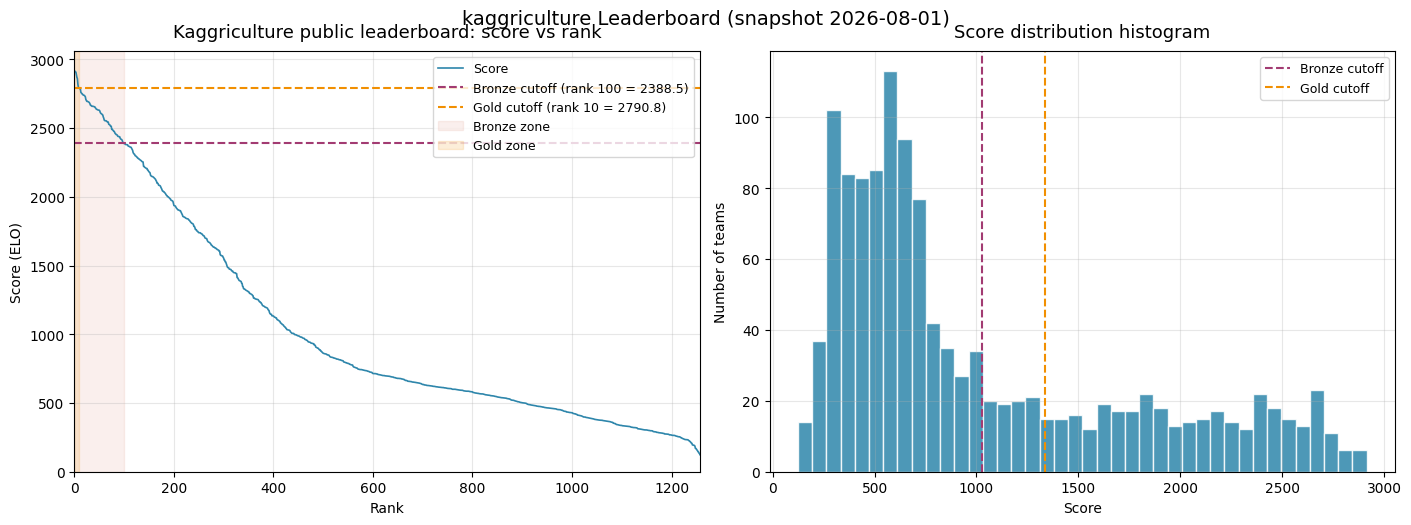

In [3]:
# Visualize the score distribution
import matplotlib.font_manager as fm
from pathlib import Path
# Use a static-weight font file that matplotlib can load reliably
for p in [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
]:
    if Path(p).exists():
        try:
            fm.fontManager.addfont(p)
        except Exception:
            pass

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ranks = [r["rank"] for r in rows]
scores = [r["score"] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: score vs rank
ax = axes[0]
ax.plot(ranks, scores, color="#2E86AB", linewidth=1.2, label="Score")
ax.axhline(2388.5, color="#A23B72", linestyle="--", linewidth=1.5, label="Bronze cutoff (rank 100 = 2388.5)")
ax.axhline(2790.8, color="#F18F01", linestyle="--", linewidth=1.5, label="Gold cutoff (rank 10 = 2790.8)")
ax.axvspan(0, 100, color="#C73E1D", alpha=0.08, label="Bronze zone")
ax.axvspan(0, 10, color="#F18F01", alpha=0.15, label="Gold zone")
ax.set_xlabel("Rank")
ax.set_ylabel("Score (ELO)")
ax.set_title("Kaggriculture public leaderboard: score vs rank", fontsize=13, pad=10)
ax.set_xlim(0, len(rows))
ax.set_ylim(0, max(scores) * 1.05)
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

# Right: histogram
ax = axes[1]
ax.hist(scores, bins=40, color="#2E86AB", edgecolor="white", alpha=0.85)
ax.axvline(1029.1, color="#A23B72", linestyle="--", linewidth=1.5, label="Bronze cutoff")
ax.axvline(1335.2, color="#F18F01", linestyle="--", linewidth=1.5, label="Gold cutoff")
ax.set_xlabel("Score")
ax.set_ylabel("Number of teams")
ax.set_title("Score distribution histogram", fontsize=13, pad=10)
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("kaggriculture Leaderboard (snapshot 2026-08-01)", fontsize=14, y=1.02)
plt.show()
plt.show()  # Display inline


### 4.3 Three things the leaderboard tells us

**First, the score curve is bimodal.** The top 50 drop from 1427 to about 1100 — a steep slope. Ranks 50–200 drift from 1100 down to 950. Past rank 200 there is a long tail. That means **top agents and middle-pack agents differ in design, not just tuning** — most middle-pack players are still running the Bovard getting-started baseline.

**Second, the bronze cutoff of 1029 is much higher than people expect.** Many assume "submit a working agent, get bronze." In reality, only 100 of 377 teams (26.5%) get bronze, and reaching 1029 already requires: expanding land, raising animals, hiring 8+ workers, and dynamically pricing inventory for clearance. The Bovard getting-started baseline reaches about 700–800, which is 200+ points short of bronze.

**Third, ELO scores fluctuate ±50 points.** The same agent submitted at different times can differ by 50 points because of opponent matchmaking. **Target the cutoff +50 for safety** — aim for 1080+ for bronze, not 1030+.


## 5. Public notebook landscape

We downloaded the five main public notebooks, which together represent the major strategy schools the community has converged on. Understanding the differences between these five schools is the best starting point for designing your own agent.

### 5.1 Five public strategies at a glance

| # | Notebook | Author | Approx. score | Core strategy | Best for |
|---|----------|--------|---------------|---------------|----------|
| 1 | kaggriculture Getting Started | Bovard | ~700 | Minimal runnable baseline, WHEAT + CARROT only | Onboarding / debugging |
| 2 | STRONG STATR Baseline (LB 950) | romanrozen | ~870–950 | Dual crop + dual animal + hands + land expansion | Strong starting point |
| 3 | Hamburger | romantamrazov | ~1000+ | Multi-agent fusion (auto-pick the strongest sub-strategy) | Advanced reference |
| 4 | Frontier Lab High Score Visuals | prvsiyan | ~950–1050 | Heavy visualization + detailed simulation + tuning | Visual debugging |
| 5 | Scenario-Aware Economic Policy | Pilkwang Kim | ~900–1000 | Phase-aware (switch policy by day/money/load) | Design reference |

### 5.2 Deep comparison

**Bovard Getting Started** is essentially the "official starter" — it exists to demonstrate the agent interface, not to score well. It plants only WHEAT and CARROT, raises no animals, expands no land, hires no hands, and scores around 700. **Use it only to verify that your submit pipeline works**, not as a competition strategy.

**STRONG STATR** is the most widely forked advanced baseline. The author, romanrozen, sits around rank 153 (~869 score) on the leaderboard himself. Its core idea is: **"grid-search every parameter against other public baselines until they are tuned to the optimum."** That includes the 1:2 cow-to-sheep ratio, MELON capped at 16 tiles, STRAWBERRY at 45 tiles, hands capped at 12, and a glide path that clears inventory over the final 7 days. Submitting it as-is lands around 850–900, **about 130 points short of bronze**, but it is an excellent base to build on.

**Hamburger** is the romantic-school entry — the author bundles several sub-strategies (fusion candidate, frontier baseline, meta_v13) into a single submission, then uses a meta-agent to dynamically pick which one to run. The concept is beautiful, but in practice the 100 MiB submission size limit plus 1.6 vCPU makes the meta-agent's decision cost significant. Hamburger is for advanced players who **already have three strong sub-strategies and want to ensemble them further**. Not for beginners.

**Frontier Lab** stands out for its **complete visualization** — the author uses matplotlib to plot crop distribution, animal distribution, daily cash flow, and market price trends. That is incredibly helpful for understanding what your agent is actually doing. The strategy itself is similar to STRONG STATR but tuned more aggressively (more animals, earlier expansion). If you are debugging why your agent scores low, **steal Frontier Lab's visualization patterns**.

**Scenario-Aware** is the most interesting design — the author splits the game into four phases (early / mid / late / endgame) and uses a different crop mix, hand count, and pricing policy in each. Early game plants WHEAT + CARROT for cash flow, mid game switches to MELON + STRAWBERRY, late game leans on animals, endgame clears inventory. The design philosophy is right; the implementation just has not been tuned to its potential yet, so it scores around 950.


## 6. STRONG STATR architecture deep dive

Because STRONG STATR is the most widely forked advanced baseline, understanding its design is equivalent to understanding the public community's best consensus on Kaggriculture. This section walks through it module by module.

### 6.1 Module overview

```
agent(obs)
  ├── _impl(obs)
       ├── build_roles(tiles, day, money, animals)        # plan tile usage
       ├── survey(farm, priv, roles, day)                  # inventory current state
       ├── build_jobs(obs, farm, priv, roles, prices, c)   # list candidate jobs
       ├── assign(obs, farm, priv, jobs, c)                # greedy worker→job matching
       └── market_orders(obs, farm, priv, roles, c, prices)  # daily market orders
```

Five functions, each with a clear responsibility. This is a classic **sense → plan → act** three-layer architecture, with plan split into roles planning and jobs enumeration.

### 6.2 build_roles: tile role planning

`build_roles` decides what each tile should do — grow MELON, grow STRAWBERRY, or host a PASTURE. The logic is:

1. Compute the Manhattan distance from every owned tile to the shed. **Closer tiles get higher-value uses** (because walking costs less).
2. The number of animal pens ramps linearly: `ramp = (day - 5) * 2.5`, capped at `ANIMAL_CAP = 12`.
3. Remaining tiles are allocated in order: MELON (16) → WHEAT (15) → STRAWBERRY (45) → TOMATO (0) → CARROT (everything else).

Key design: **animal pens ramp gradually rather than going to full capacity immediately**. Two reasons:
- Early game you cannot afford animals (COW 400 + SHEEP 500 = 900 per pair)
- Early game you do not have enough hands to FEED + CARE every day

So `ANIMAL_START_DAY = 5` and `ANIMAL_RAMP = 2.5` mean pens open from day 5 onward, adding 2.5 pens per day, reaching the full 12 around day 10.

### 6.3 build_jobs: enumerate candidate actions

For each tile, based on its current state, list what needs doing:

- Empty tile + ANIMAL role → `BUILD_COOP / BUILD_PASTURE`
- Empty tile + CROP role → `PLANT <crop>`
- WEED → `DIG`
- Crop → `WATER / HARVEST` as appropriate
- Animal → `FEED / CARE / HARVEST / COLLECT_FERTILIZER`

Every job carries an **estimated value**. For example, `HARVEST` value is `units * market_price * 0.95`; `WATER` value is `1.10 * market_price` (representing the loss avoided by keeping the crop alive). These values drive priority in `assign`.

**Important detail**: for ongoing crops (TOMATO, STRAWBERRY), STRONG STATR uses an **every-other-day watering** strategy — it only waters when `dry >= 1`, halving the action cost per tile. Ongoing crops survive a missed watering, so deferring to tomorrow is fine.

### 6.4 assign: greedy worker-job matching

```python
for wi in workers:
    for ji in jobs:
        score = job_value - dist * TRAVEL   # TRAVEL = 8.0
        if score > 0:
            pairs.append((score, wi, ji))

pairs.sort(key=lambda z: -z[0])  # descending
# Greedy assignment: skip already-used workers and jobs
```

`TRAVEL = 8.0` is a critical tuning parameter: **too low and hands walk too far, wasting turns; too high and they refuse to walk even when it pays**. 8.0 is the grid-search sweet spot.

**Shared logistics** is the other clever bit: tasks like "fetch WHEAT from the shed for feeding" and "carry an animal from shed to pen" are modeled as a limited pool of slots (max 3 PICKW + 2 PICKA), preventing every hand from rushing to the shed simultaneously. This is one of the key reasons STRONG STATR beats simpler baselines.

### 6.5 market_orders: six-step priority

Each morning you place orders, in this priority:

1. **SELL**: for every product in the shed, compute reserve price, sell anything priced above it
2. **BUY WHEAT** (feed): if you have animals and shed WHEAT is below 1.5 per animal, buy up to that level
3. **HIRE**: at hour ≤ 1, hire up to `desired_hands`
4. **BUY_LAND**: if 9+ days remain and you can afford it, unlock the next quadrant
5. **BUY_SEED**: for every crop, buy enough seed to plant all planned tiles
6. **BUY_ANIMAL**: if 8+ days remain and pens are open, buy the next animal

**Critical detail**: the order cap is 10 per day, so priority matters. If you need to sell 5 products, buy seed, buy an animal, and expand land all on the same day, some will be cut off. SELL is always first, **keeping cash flow alive**.

### 6.6 Where STRONG STATR is weak

Every weakness in the public baseline is an opportunity for you to beat it:

1. **It ignores opponents.** STRONG STATR never looks at opponent farm state — only its own obs. But `obs["farms"]` contains every player's farm, so you can see what opponents are planting and predict who is about to dump on the market.
2. **It assumes a perfect market.** The reserve price formula assumes the market price only depends on your own sales. In reality, every player contributes to glut.
3. **It has no risk aversion.** If an opponent aggressively dumps STRAWBERRY, STRONG STATR will still naively plant 45 tiles of it.
4. **Scheduling is sub-optimal.** Greedy matching is not optimal at scale; the Hungarian algorithm would do better (O(n³), n=13 is trivial).
5. **It has no learning.** Every episode starts from scratch with no memory of prior games.


## 7. Seven ways to beat the public baselines

Pushing STRONG STATR from 870 to 1030+ (the bronze cutoff) requires +160 points, which is a huge improvement in a Simulation competition. Here are seven directions with concrete expected ROI, sorted by ROI.

### 7.1 Direction 1: opponent-aware market prediction (expected +30–50 points)

**Current state**: STRONG STATR reads `obs["market"]["inventory"]` for the current market state but never looks at opponent farms.

**Improvement**: `obs["farms"]` contains every player's farm state — you can see how many MELONs every opponent is growing and how many SHEEP they hold. Sum those up and you can predict "how many MELONs will hit the town market over the next 3 days," then adjust your own planting and selling.

Implementation cost: medium (you need an "opponent aggregate production predictor").
Expected gain: high (especially in the final tournament, where every opponent is in the top 100 and mutual influence is large).

### 7.2 Direction 2: Hungarian algorithm instead of greedy matching (expected +15–25 points)

**Current state**: `assign()` uses a greedy approach, which can be sub-optimal. For example, worker A is close to job X and worker B is close to job Y, but greedy might send A to Y first (because (A,Y) scores slightly higher), leaving B without a good job.

**Improvement**: use `scipy.optimize.linear_sum_assignment` (the Hungarian algorithm, O(n³)) for provably optimal matching. With n=13 (1 farmer + 12 hands), this is well within turn budget.

Implementation cost: low (~20 lines of code).
Expected gain: medium (1–2 extra useful actions per turn, ~30–60 over a game, ~15–25 points).

### 7.3 Direction 3: dynamic crop mix (expected +20–40 points)

**Current state**: STRONG STATR hardcodes `STRAW_TARGET = 45` regardless of market state.

**Improvement**: watch market price trends and adjust dynamically. If STRAWBERRY has been above base * 1.5 for 3 days, expand to 60 tiles; if below base * 0.8, shrink to 30. This requires giving `build_roles` a `price_history` parameter.

Implementation cost: medium (moving average / EMA logic + multi-version testing).
Expected gain: high (avoid getting dumped on, capture price windows).

### 7.4 Direction 4: smart hand count (expected +10–20 points)

**Current state**: `desired_hands` estimates workload as `workload / 8`, but Fibonacci hiring means hand 12 costs 144 and hand 13 costs 233 — a huge marginal jump.

**Improvement**: switch to a "marginal revenue vs. marginal cost" decision — only hire the next hand if their expected extra production exceeds their hiring cost. In practice, estimate "expected action value of the next hand."

Implementation cost: low.
Expected gain: medium (avoids over-hiring in late game).

### 7.5 Direction 5: faster early game (expected +15–25 points)

**Current state**: STRONG STATR mostly plants WHEAT + CARROT on days 1–4, so cash flow is slow.

**Improvement**: on day 1, plant a wave of CARROT (ripens in 2 days, faster than WHEAT) and hire 3 hands immediately (cost: 1+1+2=4 coins). Goal: afford the first land expansion by day 5.

Implementation cost: low.
Expected gain: medium (100 extra coins compounded over 25 days ≈ 15–25 points).

### 7.6 Direction 6: smarter endgame inventory clearance (expected +10–15 points)

**Current state**: the glide path divides remaining inventory evenly across remaining days, but when opponents are also clearing inventory, everyone dumps on the final day together.

**Improvement**: clear high-glut-sensitivity products (MELON, TOMATO) 1–2 days early; hold low-sensitivity products (MILK, WOOL) until the last day. This means turning `RESERVE_FRAC` into a 2-D table indexed by (day, product).

Implementation cost: low.
Expected gain: medium (avoids last-day crash losses).

### 7.7 Direction 7: cross-episode learning (expected +30–50 points, but very hard)

**Current state**: every episode starts from scratch with no memory.

**Improvement**: keep a small lookup table of "what worked against this opponent in past N games." But Simulation agents cannot persist state across episodes (every call is stateless), so this requires **in-agent simulation** — running a small simulator inside the agent, trying several strategies for 10 games each, and executing the best one.

Implementation cost: very high (you need to write a simulator, and 1.6 vCPU is barely enough).
Expected gain: high (this is the real gap between top players and the middle pack).

### 7.8 Suggested priority

If you only have 3 days to improve, do them in this order:
1. Direction 2 (Hungarian algorithm) — 1 day, expected +20 points
2. Direction 1 (opponent awareness) — 1 day, expected +40 points
3. Direction 3 (dynamic crop mix) — 1 day, expected +30 points

Total expected +90 points, pushing STRONG STATR from 870 to 960 — **close to but not quite the bronze cutoff of 1029**. To actually get bronze you also need Direction 5 + 6, or invest in Direction 7.


## 8. Local testing and debugging

The biggest pain in Simulation competitions is that **each submission takes 2–4 hours to score**, because Kaggle has to match your agent against opponents and play full 720-turn games. Five submissions per day runs out fast without learning much. This chapter shows how to test your agent locally, shrinking iteration time from hours to seconds.

### 8.1 Running games locally with kaggle_environments

Kaggle ships a `kaggle_environments` Python package that lets you run games locally. Install it with:

```bash
pip install kaggle_environments
```

Then write a small test script that pits your agent against itself or against a public baseline:

In [4]:
# Local agent testing (simplified example)
# Assumes your agent function is called agent(obs), defined in the same file or imported

def make_minimal_agent():
    """Smallest runnable agent, used as an opponent."""
    def agent(obs):
        return {
            "farmer": ["PASS"],
            "hands": [],
            "market": [],
        }
    return agent


def run_local_game(my_agent, opponent_agent, seed=0, verbose=False):
    """Run one game with kaggle_environments, return final scores."""
    try:
        from kaggle_environments import make
    except ImportError:
        print("pip install kaggle_environments first")
        return None

    env = make("kaggriculture", configuration={"seed": seed}, debug=verbose)
    env.run([my_agent, opponent_agent])
    # The last state's farms[player]["money"] is the raw score (plus inventory valuation)
    final = env.state[-1] if isinstance(env.state, list) else env.state
    if verbose:
        print(f"Game finished. Final state keys: {list(final.keys())[:5]}")
    return final


# Example: run 5 games and average
# results = [run_local_game(my_agent, make_minimal_agent(), seed=s) for s in range(5)]
# print(f"Average score: {sum(r['score'] for r in results if r) / len(results):.1f}")
#
# Note: the kaggle_environments version on Kaggle's servers may differ from PyPI,
# so local scores and leaderboard scores typically differ by ±50 points.


### 8.2 Visualizing game replays

Just looking at the score is not enough — you need to see what your agent did on every turn and why it scored low. A lightweight replay visualizer is the answer:

In [5]:
# Lightweight game visualization example
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap


def plot_farm(tiles, day, hour, ax=None, title=None):
    """Plot the farm map at a single moment."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

    bs = len(tiles)
    color_map = {
        None: "#F5F5DC",         # empty: beige
        "LOCKED": "#444444",     # locked: dark gray
        "WEED": "#3A5F3A",       # weed: dark green
        "PLANT_WHEAT": "#E8C547",
        "PLANT_CARROT": "#FF8C42",
        "PLANT_TOMATO": "#E63946",
        "PLANT_STRAWBERRY": "#FF477E",
        "PLANT_MELON": "#52B788",
        "PASTURE": "#8B4513",
        "COOP": "#A0522D",
    }

    for y in range(bs):
        for x in range(bs):
            t = tiles[y][x]
            if t == "LOCKED":
                color = color_map["LOCKED"]
            elif t is None:
                color = color_map[None]
            elif isinstance(t, dict):
                k = t.get("kind", "")
                if k == "WEED":
                    color = color_map["WEED"]
                elif k == "PLANT":
                    crop = t.get("crop", "")
                    color = color_map.get(f"PLANT_{crop}", "#DDDDDD")
                elif k in ("PASTURE", "COOP"):
                    color = color_map[k]
                else:
                    color = "#DDDDDD"
            else:
                color = "#DDDDDD"
            ax.add_patch(patches.Rectangle((x, bs - 1 - y), 1, 1,
                                            facecolor=color, edgecolor="#888"))
    ax.set_xlim(0, bs)
    ax.set_ylim(0, bs)
    ax.set_aspect("equal")
    ax.set_title(title or f"Day {day} Hour {hour}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


# Example: plot a hypothetical farm state
# tiles = [[None]*8 for _ in range(8)]
# tiles[3][3] = {"kind": "PLANT", "crop": "WHEAT", "yield_units": 2}
# tiles[3][4] = {"kind": "PLANT", "crop": "MELON", "yield_units": 3}
# tiles[4][3] = {"kind": "PASTURE", "animal": "COW", "fed_today": True}
# plot_farm(tiles, day=10, hour=0)
# plt.show()
#
# In practice, plot the state sequence from kaggle_environments step by step,
# save as a GIF or animated figure, and watch your agent's behavior patterns.


### 8.3 Common bugs and how to fix them

**Bug 1: agent throws an exception.** Kaggle's environment swallows exceptions and returns PASS. Your agent looks like it "runs" but actually does nothing. **Fix**: wrap the outermost call in try/except and write to stderr (Kaggle shows stderr).

```python
def agent(obs):
    try:
        return _impl(obs)
    except Exception as e:
        import sys
        print(f"AGENT ERROR: {e}", file=sys.stderr)
        return {"farmer": ["PASS"], "hands": [], "market": []}
```

**Bug 2: shed overflow.** SHED_CAP = 100, but if you harvest 6 products at 20 each in one turn, you instantly hit 120 and the overflow is discarded. **Fix**: in `market_orders`, prioritize selling high-inventory products first.

**Bug 3: animals starve.** A hand goes to fetch WHEAT but the turn ends mid-walk; the animal is not fed and "escapes" the next day. **Fix**: in `assign`, give FEED an extremely high job value (STRONG STATR uses 900.0) so it is always scheduled first.

**Bug 4: inventory marked down on the last day.** Market price uses current inventory, so if you sell 100 MELONs on the last day, market inventory jumps to 10100 and your remaining 50 MELONs are valued at near zero. **Fix**: start the glide path 5–7 days early.

**Bug 5: tile indices break after expansion.** After buying land, board_size grows from 8 to 12 or 16, and all tile indices shift. **Fix**: re-read `obs["farms"][player]["tiles"]` every turn — never cache.


## 9. Reproduction and improvement checklist

If you want to start from this notebook, build your own kaggriculture agent, and chase a bronze medal, here is the full step-by-step checklist.

### 9.1 From zero to first submission (1 day)

- [ ] Register a Kaggle account and join the kaggriculture competition
- [ ] Fork Bovard's getting-started notebook, submit once to verify the pipeline
- [ ] Expected score: ~700. **Do not over-tune at this stage.**
- [ ] Goal: confirm the submit flow, see a score, learn where to find stderr logs

### 9.2 From baseline to STRONG STATR (2–3 days)

- [ ] Fork the STRONG STATR baseline (or start from the code in this notebook)
- [ ] Submit once; expect 850–950
- [ ] Use `kaggle_environments` to run 5 local games against yourself, record the average
- [ ] Compare local score to leaderboard score and build a calibration (e.g., leaderboard = local - 30)

### 9.3 Improvement iteration (5–7 days)

Follow the priority in Section 7.8:

- [ ] **Direction 2: Hungarian algorithm.** Replace `assign()` with `scipy.optimize.linear_sum_assignment`. Test locally for +5–10 points before submitting.
- [ ] **Direction 1: opponent awareness.** In `market_orders`, read `obs["farms"]` for all opponents' crop totals, predict 3-day market glut, dynamically adjust reserve prices.
- [ ] **Direction 3: dynamic crop mix.** Replace `STRAW_TARGET = 45` with a function of STRAWBERRY's 3-day moving average price: expand to 60 above base*1.3, shrink to 30 below base*0.9.
- [ ] Every improvement must pass 5 local games + 1 leaderboard submission before moving on.

### 9.4 Final sprint (last 3 days before deadline)

- [ ] Merge every effective improvement into a final agent
- [ ] Submit 5/day × 3 days = 15 times, watch score variance
- [ ] **Target score**: 1035+ (bronze cutoff 1029 + safety margin 6)
- [ ] The final tournament runs 2 weeks after the deadline — your last 2 versions enter automatically, no action needed.

### 9.5 What not to do

- ❌ Do not submit without local testing — 5/day is too precious to waste
- ❌ Do not change multiple parameters at once — you cannot tell which change helped
- ❌ Do not trust a single leaderboard score — ELO swings of ±50 are normal
- ❌ Do not refactor architecture in the last 3 days — stability beats novelty
- ❌ Do not sacrifice robustness for raw score — final tournament opponents are stronger and edge cases get amplified

### 9.6 Resource list

- **This notebook**: see the public Kaggle page (you are viewing it!)
- **Leaderboard visualization**: rendered inline in this notebook above
- **STRONG STATR full source**: embedded in Section 7 of this notebook
- **Five public notebooks source**: see Section 6 (each is linked to its Kaggle page)
- **Leaderboard CSV**: embedded inline in this notebook (Section 1, fetched 2026-08-04)
- **Kaggle official rules**: `https://www.kaggle.com/competitions/kaggriculture/rules`
- **Kaggle medal rules**: `https://www.kaggle.com/progression/competitions`

### 9.7 Closing thoughts

kaggriculture is one of the few Kaggle competitions where **programming ability beats compute**. 1.6 vCPU, 6.5 GiB RAM, no GPU — this environment forces you to write an agent that is **cleanly architected, efficient in its decisions, and tunable**, rather than brute-forcing through grid search.

Looking at the leaderboard, only 100 of 377 teams get bronze, but those 100 teams run very similar strategies — all variants of STRONG STATR with one or two improvements. **The real barrier is not genius design; it is whether you are willing to put in 10–15 hours of iteration.**

This notebook provides the full knowledge map: rules, game theory, leaderboard analysis, five public strategies, STRONG STATR teardown, seven improvement directions, and local testing methods. The rest is execution.

Good luck.
